In [259]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
import warnings

# Data Cleaning and Preprocessing

### Step 1: Data Loading

In [260]:
# Load the dataset
data = pd.read_csv("clyde.CSV")

In [261]:
data.shape

(12, 97)

In [262]:
data.columns

Index(['Site', 'Abra alba', 'Abra nitida', 'Abra sp.', 'Amaeana trilobata',
       'Ampharete grubei', 'Amphipoda sp. indet.', 'Amphitritinae',
       'Amphiura chiajei', 'Amphiura filiformis', 'Amphiura sp.',
       'Ancistrosyllis groenlandica', 'Anthozoa', 'Aphrodita aculeata',
       'Aricidea catherinae', 'Brissopsis lyrifera', 'Calocaris macandreae',
       'Capitella capitata', 'Caulleriella sp.', 'Chaetoderma sp',
       'Chaetozone setosa', 'Cirratulidae', 'Cirratulus cirratus', 'Copepoda',
       'Corbula gibba', 'Cumacea', 'Diplocirrus glaucus', 'Dodecaceria sp.',
       'Ephesiella abyssorum', 'Eteone longa', 'Eulalia viridis', 'Gastropoda',
       'Glycera alba', 'Glycera sp.', 'Golfingia sp.', 'Goniada maculata',
       'Hemichordata', 'Kefersteinia cirrata', 'Levinsenia gracilis',
       'Lipobranchius jeffreysii', 'Litocorsa stremma',
       'Lumbrineris hibernica', 'Malacoceros fuliginosus',
       'Mediomastus fragilis', 'Melinna palmata', 'Mya truncata',
       'Myse

In [263]:
# Display the first few rows of the dataset to understand its structure
data.head()

,Site,Abra alba,Abra nitida,Abra sp.,Amaeana trilobata,Ampharete grubei,Amphipoda sp. indet.,Amphitritinae,Amphiura chiajei,Amphiura filiformis,...,Mn,Co,Ni,Zn,Cd,Pb,Cr,Dep,%C,%N
0,S1,0,22,0,0,0,0,0,30,10,...,2470,14,34,160,0.0,70,53,144,3.0,0.53
1,S2,0,6,0,3,1,0,0,51,11,...,1170,15,32,156,0.2,59,15,152,3.0,0.46
2,S3,0,5,0,54,1,0,0,10,10,...,394,12,38,182,0.2,81,77,140,2.9,0.36
3,S4,0,4,0,0,0,0,0,25,0,...,349,12,41,227,0.5,97,113,106,3.7,0.46
4,S5,0,0,0,1,3,0,0,0,0,...,317,10,37,329,2.2,137,177,112,5.6,0.69


In [264]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 97 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Site                         12 non-null     object 
 1   Abra alba                    12 non-null     int64  
 2   Abra nitida                  12 non-null     int64  
 3   Abra sp.                     12 non-null     int64  
 4   Amaeana trilobata            12 non-null     int64  
 5   Ampharete grubei             12 non-null     int64  
 6   Amphipoda sp. indet.         12 non-null     int64  
 7   Amphitritinae                12 non-null     int64  
 8   Amphiura chiajei             12 non-null     int64  
 9   Amphiura filiformis          12 non-null     int64  
 10  Amphiura sp.                 12 non-null     int64  
 11  Ancistrosyllis groenlandica  12 non-null     int64  
 12  Anthozoa                     12 non-null     int64  
 13  Aphrodita aculeata    

### Step 2: Data Cleaning and Summary

In [265]:
data.describe()

,Abra alba,Abra nitida,Abra sp.,Amaeana trilobata,Ampharete grubei,Amphipoda sp. indet.,Amphitritinae,Amphiura chiajei,Amphiura filiformis,Amphiura sp.,...,Mn,Co,Ni,Zn,Cd,Pb,Cr,Dep,%C,%N
count,12.000000,12.000000,12.0,12.000000,12.000000,12.0,12.0,12.000000,12.000000,12.000000,...,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,33.583333,3.250000,0.0,6.333333,0.500000,0.0,0.0,24.250000,6.333333,0.166667,...,598.666667,11.250000,32.916667,238.083333,1.275000,105.333333,112.833333,99.166667,4.400000,0.528333
std,66.206919,6.311966,0.0,15.203668,0.904534,0.0,0.0,42.170918,7.559862,0.577350,...,653.671078,2.261335,6.487167,165.498947,1.830611,79.219297,92.138072,31.021498,2.776198,0.216032
min,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,194.000000,6.000000,16.000000,89.000000,0.000000,42.000000,15.000000,64.000000,1.900000,0.290000
25%,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,254.250000,10.000000,32.750000,118.750000,0.100000,56.500000,51.750000,78.500000,2.750000,0.375000
50%,0.000000,0.000000,0.0,1.500000,0.000000,0.0,0.0,5.000000,4.000000,0.000000,...,337.500000,11.500000,34.000000,171.000000,0.300000,75.500000,67.000000,83.000000,3.100000,0.460000
75%,25.500000,4.250000,0.0,3.750000,1.000000,0.0,0.0,28.500000,10.250000,0.000000,...,529.500000,12.000000,37.000000,301.250000,2.200000,131.750000,178.250000,119.000000,5.900000,0.607500
max,210.000000,22.000000,0.0,54.000000,3.000000,0.0,0.0,147.000000,23.000000,2.000000,...,2470.000000,15.000000,41.000000,652.000000,5.700000,319.000000,314.000000,152.000000,11.200000,1.070000


In [266]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 Site                 0
Abra alba            0
Abra nitida          0
Abra sp.             0
Amaeana trilobata    0
                    ..
Pb                   0
Cr                   0
Dep                  0
%C                   0
%N                   0
Length: 97, dtype: int64


### Step 3: Visualize the Data

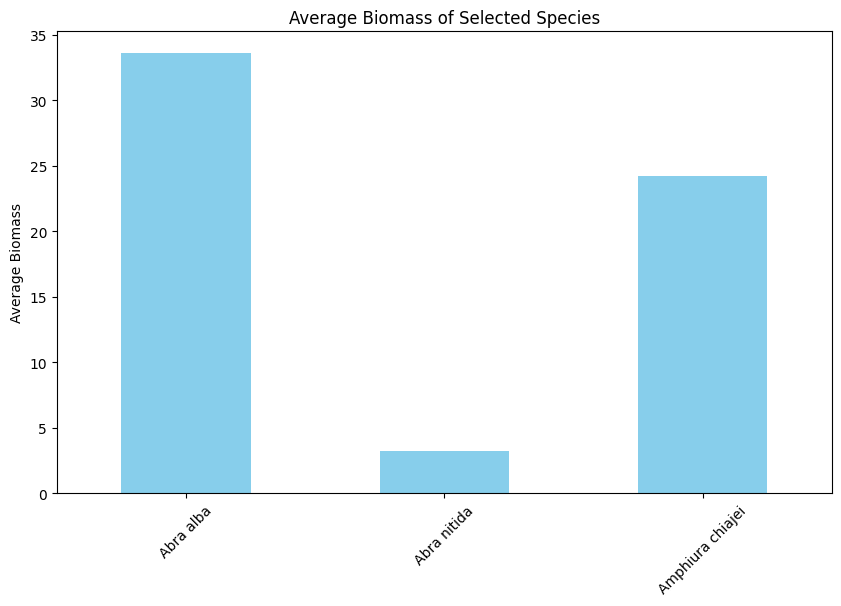

In [267]:
# 1. Bar chart: Average biomass of selected species
species_columns = ['Abra alba', 'Abra nitida', 'Amphiura chiajei']
avg_biomass = data[species_columns].mean()

plt.figure(figsize=(10, 6))
avg_biomass.plot(kind='bar', color='skyblue')
plt.title('Average Biomass of Selected Species')
plt.ylabel('Average Biomass')
plt.xticks(rotation=45)
plt.show()


In [268]:
# Identify species columns
# Filter out non-species columns based on their names
non_species_columns = ['Site','Total Biomass', 'Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', 'Dep', '%C', '%N']
species_columns = [col for col in data.columns if col not in non_species_columns]


In [269]:
# Calculate average biomass for species columns
avg_biomass = data[species_columns].mean()

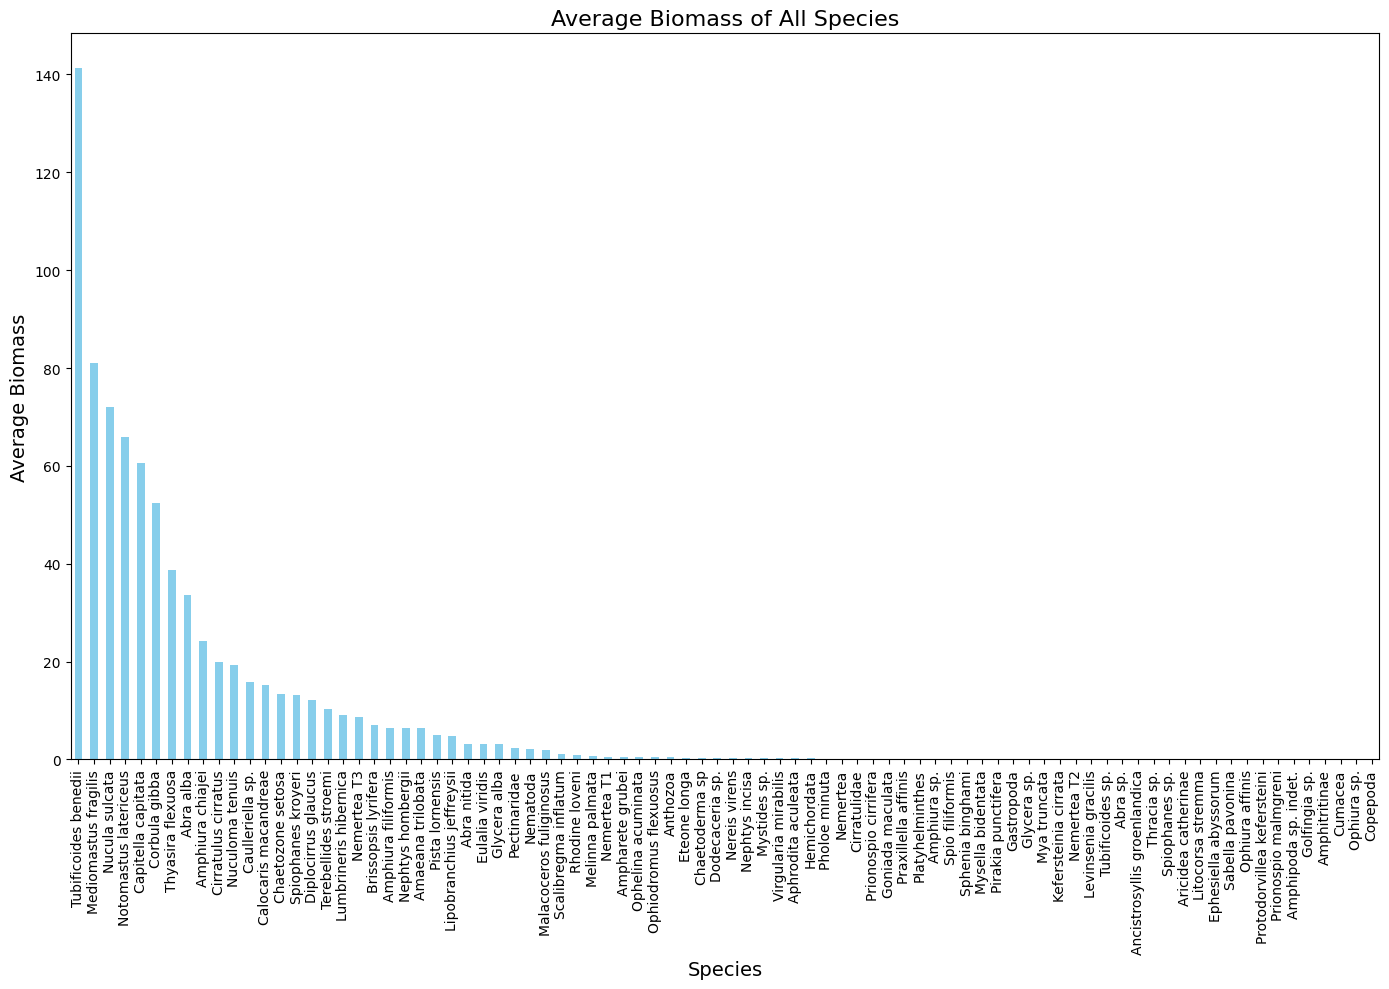

In [270]:
# 2.  Plot the average biomass of all the species
plt.figure(figsize=(14, 10))  # Adjust size for better visualization
avg_biomass.sort_values(ascending=False).plot(kind='bar', color='skyblue')  # Sort for better visual comparison
plt.title('Average Biomass of All Species', fontsize=16)
plt.ylabel('Average Biomass', fontsize=14)
plt.xlabel('Species', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()  # Ensure labels fit well
plt.show()

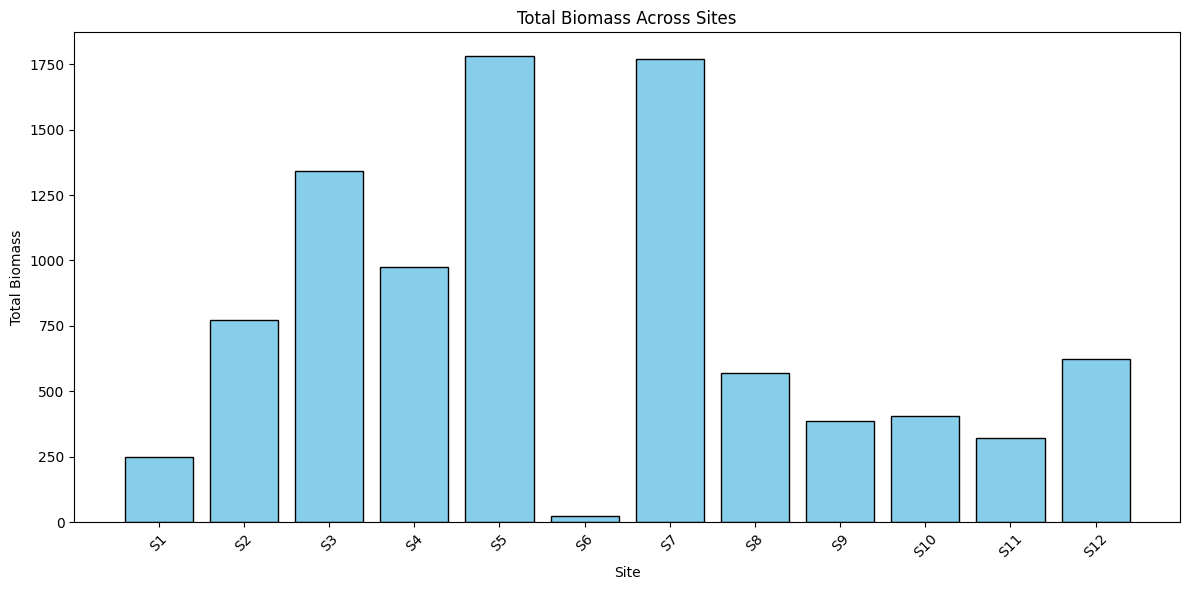

In [271]:
#3.  Bar chart: Total biomass per site
plt.figure(figsize=(12, 6))
plt.bar(data['Site'], data['Total Biomass'], color='skyblue', edgecolor='black')
plt.title('Total Biomass Across Sites')
plt.xlabel('Site')
plt.ylabel('Total Biomass')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation - Sites like S5 and S7, with the highest biomass (~1750), may indicate areas of high productivity or favorable conditions. In contrast, S6, with the lowest biomass (~10), could reflect limited resources or environmental disturbances. Other sites show varying biomass levels, with moderate values at S3, S4, S8, and S12, while S1, S9, S10, and S11 exhibit relatively lower values.

In [272]:
# Calculate species diversity as the count of non-zero species biomass
data['Species Diversity'] = (data[species_columns] > 0).sum(axis=1)

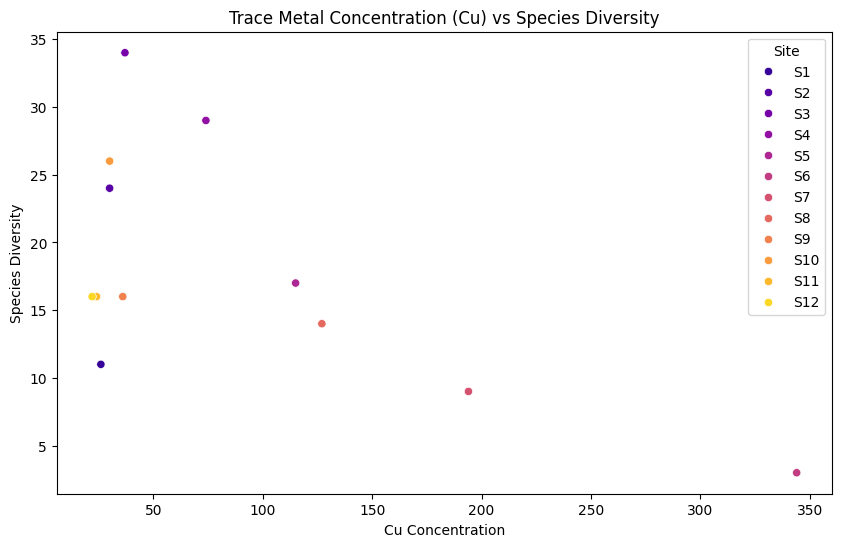

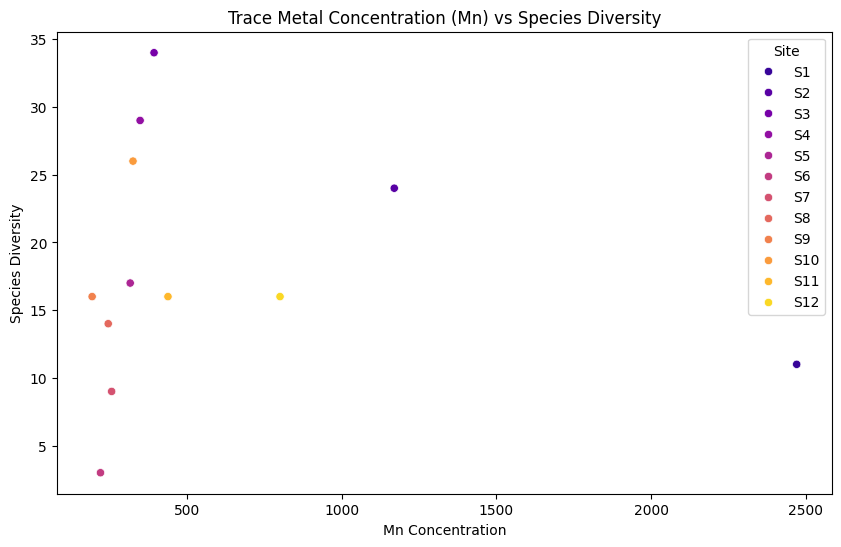

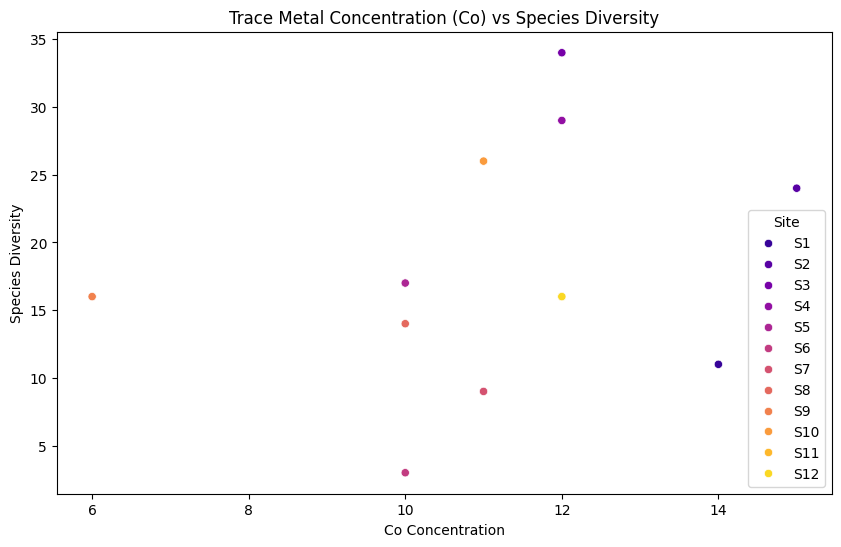

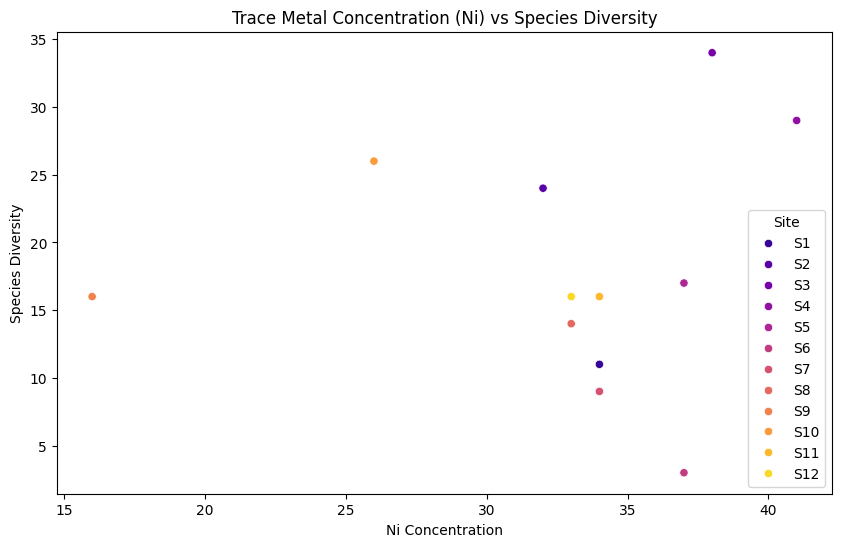

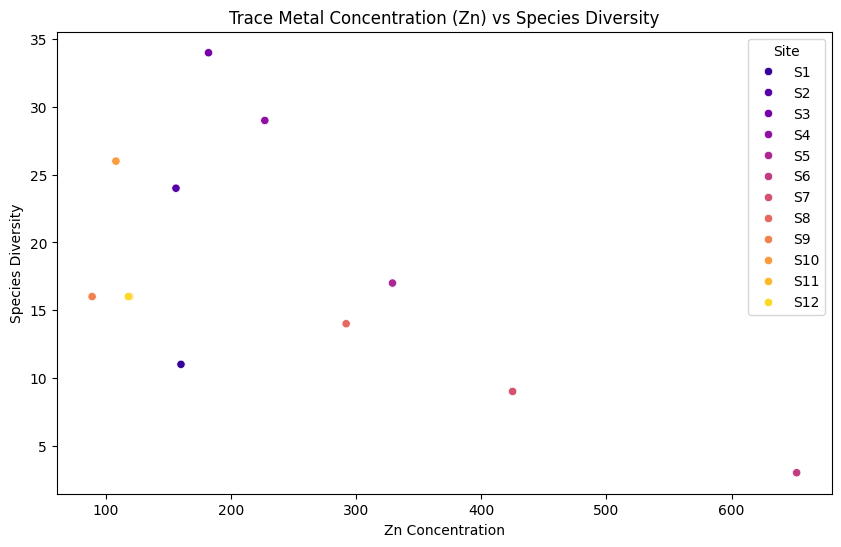

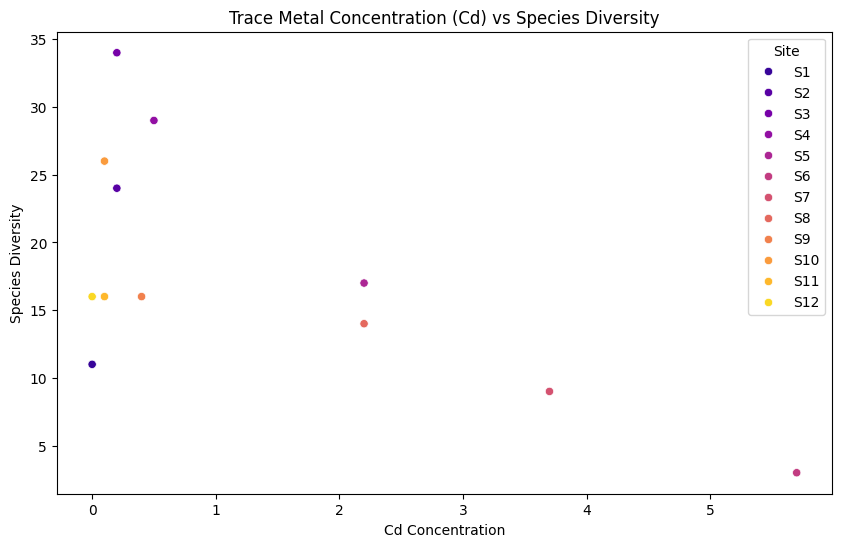

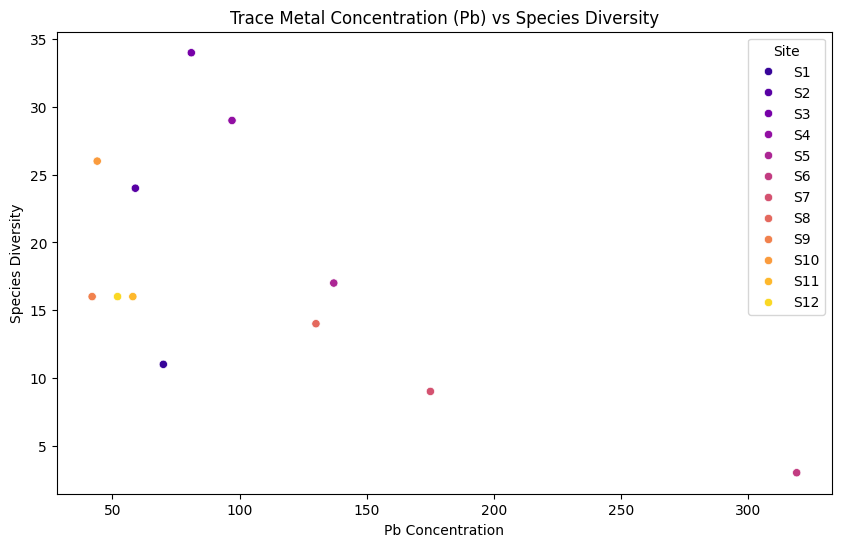

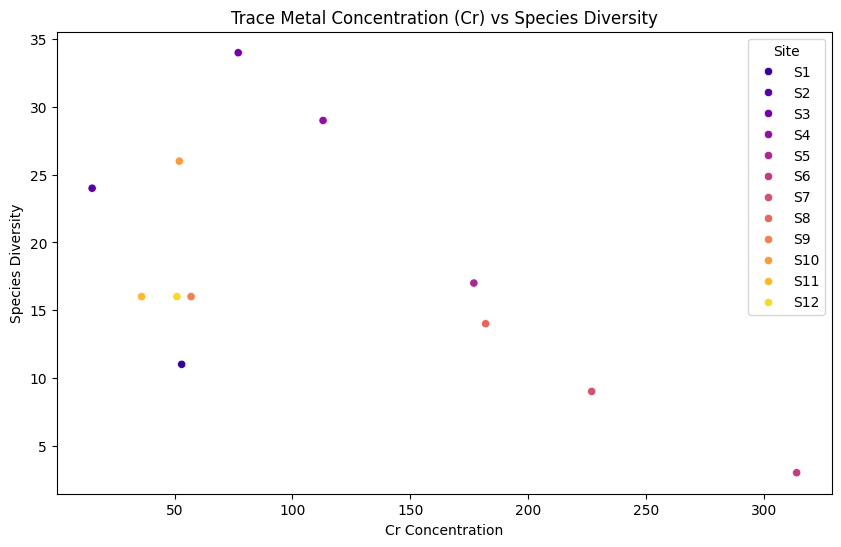

In [273]:
# 4. scatter plots for trace metals VS Species Diversity
for metal in ['Cu', 'Mn','Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr']:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=data[metal], y=data['Species Diversity'], hue=data['Site'], palette='plasma')
    plt.title(f'Trace Metal Concentration ({metal}) vs Species Diversity')
    plt.xlabel(f'{metal} Concentration')
    plt.ylabel('Species Diversity')
    plt.legend(title='Site')
    plt.show()


Insights:
For Co and Ni concentrations, higher metal levels are associated with greater species diversity. However, for all other metals, lower concentrations correlate with higher species diversity, each following its own distinct pattern. This suggests that Co and Ni concentrations do not significantly affect species diversity.


Patterns: Look for trends, such as higher diversity at specific trace metal concentration ranges.
Outliers: Identify sites or metals that deviate from general patterns.

In [274]:
# 5. Total Biomass and Trace Metal Concentrations Across Sites

# Trace metal columns
trace_metals = ['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr']

# Prepare data for plotting
sites = data['Site']
total_biomass = data['Total Biomass']
trace_metal_data = data[trace_metals]

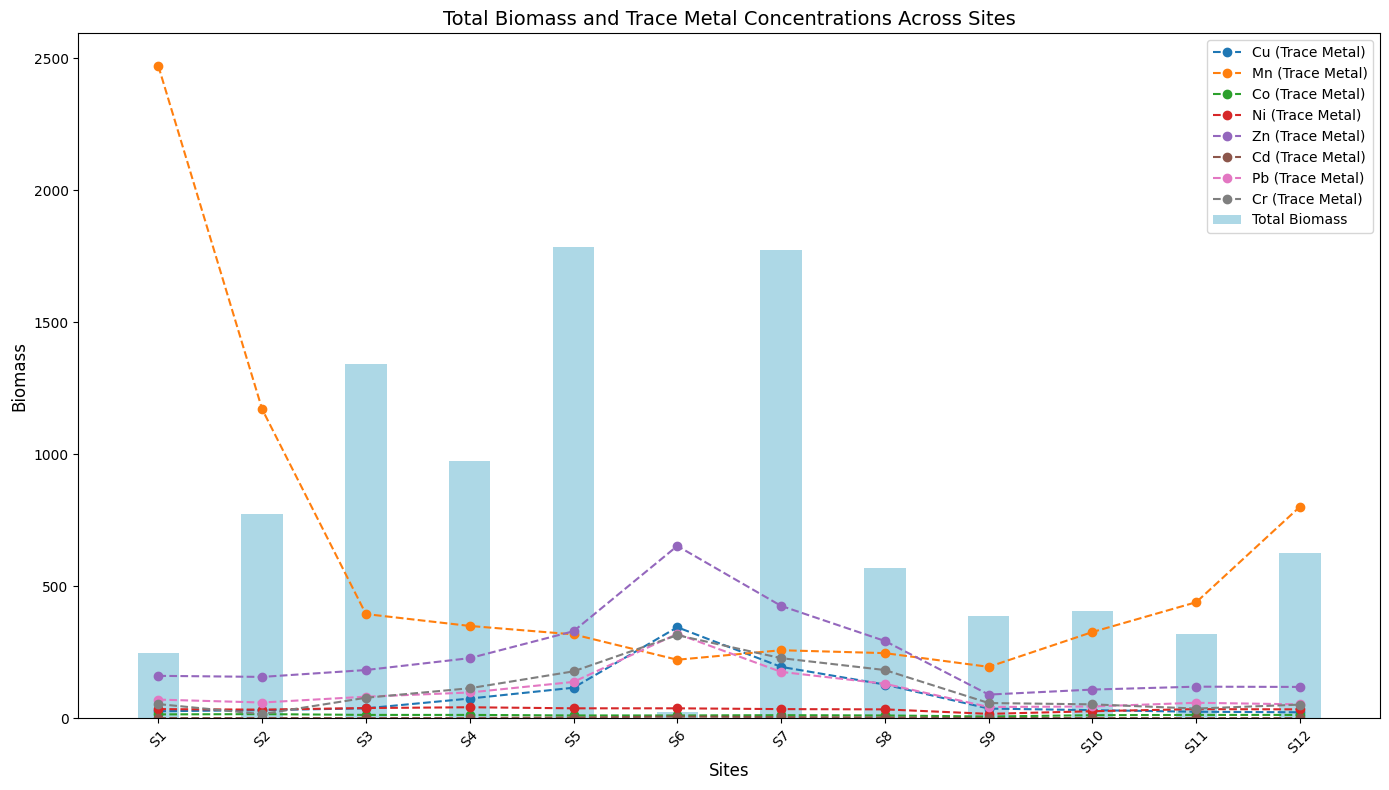

In [275]:
# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot total biomass as bars
bar_width = 0.4
x = np.arange(len(sites))  # X-axis positions
ax1.bar(x, total_biomass, bar_width, label='Total Biomass', color='lightblue')

# Plot trace metals as lines
for metal in trace_metals:
    ax1.plot(x, trace_metal_data[metal], label=f'{metal} (Trace Metal)', marker='o', linestyle='--')

# Formatting
ax1.set_title('Total Biomass and Trace Metal Concentrations Across Sites', fontsize=14)
ax1.set_xlabel('Sites', fontsize=12)
ax1.set_ylabel('Biomass', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(sites, rotation=45)
ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

Insights:

Mn (orange) shows significant variation, with sharp spikes at S1 and S12.
Zn, Cu, Pb, and Cd exhibit higher concentrations at S6.
Ni, Co, and Cr demonstrate consistent trends across sites, with negligible variations and relatively low concentrations.
Key Patterns:

At S6, where Zn, Cu, Pb, and Cd concentrations peak, biomass is notably low.
Mn spikes at S1 and S12, possibly indicating localized environmental factors (e.g., industrial waste).
S2 and S12 exhibit similar Mn concentrations and comparable biomass levels.
Sites with higher biomass (S3, S4, S5, and S7) do not show consistent correlations with elevated trace metal concentrations.

### Step 4: Correlation Analysis

In [276]:
# Select relevant columns (species, trace metals, organic content)
selected_columns = ['Total Biomass', 'Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr'] 

# Compute correlation matrix
correlation_matrix = data[selected_columns].corr()

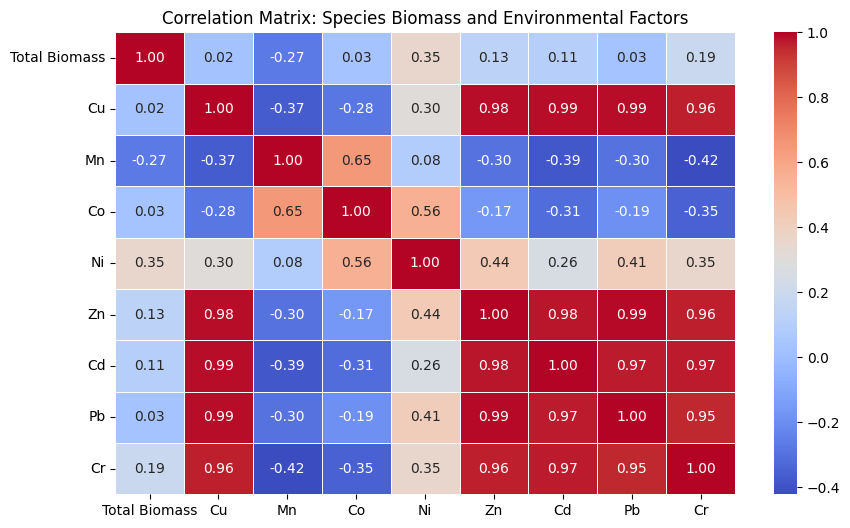

In [277]:
#5.  correlations between environmental parameters and species biomass.
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Species Biomass and Environmental Factors')
plt.show()

In [278]:
# Select relevant columns (species, trace metals, organic content)
selected_columns = ['Species Diversity', 'Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr'] 

# Compute correlation matrix
correlation_matrix = data[selected_columns].corr()

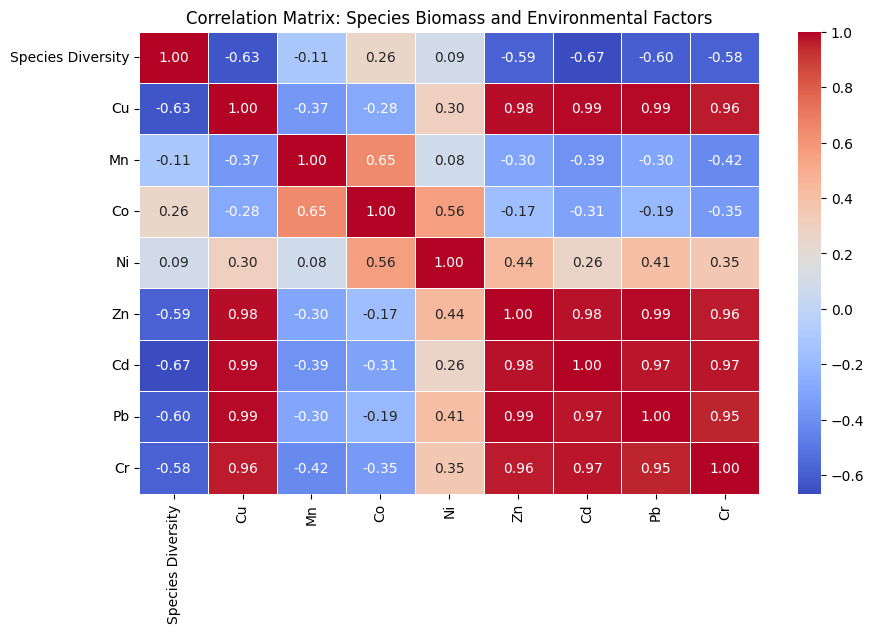

In [279]:
#5.  correlations between environmental parameters and species Diversity.
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Species Biomass and Environmental Factors')
plt.show()

Species Diversity vs. Heavy Metals:

Species diversity negatively correlates with most heavy metals (e.g., Cu: -0.63, Zn: -0.59, Cd: -0.67, Pb: -0.60, Cr: -0.58).
This suggests that higher concentrations of these metals might negatively impact biodiversity.
Heavy Metals Intercorrelations:

Strong positive correlations exist among Cu, Zn, Cd, Pb, and Cr (e.g., Cu-Zn: 0.98, Cu-Cd: 0.99, Zn-Cd: 0.98, Pb-Zn: 0.99).
This could indicate common pollution sources or similar geochemical behaviors.

Implications:
The negative correlation between species diversity and most heavy metals suggests potential ecological risks.
The high correlation among certain metals indicates they may originate from the same pollution source.

Total Biomass:

Has a weak positive correlation with Ni (0.35) and Cr (0.19), suggesting a slight association with these metals.
Shows a weak negative correlation with Mn (-0.27), indicating that as Mn increases, Total Biomass tends to decrease slightly.
Minimal correlation with other metals like Cu, Zn, Cd, and Pb (close to 0), implying little to no relationship.

Strong Inter-Metal Correlations:

Cu, Zn, Cd, Pb, and Cr show very strong positive correlations with each other (values close to 0.95 - 1.0), suggesting they co-occur in similar environmental conditions or have shared sources.
Mn correlates moderately with Co (0.65) but negatively with most other metals like Cu (-0.37) and Cr (-0.42).


Implications:
The negative correlation between Mn and Total Biomass, even though it is weak suggests that it is affecting Biomass at some levels. 
The weak correlations between Total Biomass and other trace metals suggest that biomass distribution may not be directly controlled by the concentrations of these metals. Other environmental factors (e.g., salinity, or dissolved oxygen) could play a more significant role, for which i dont have the data. 
Strong inter-metal correlations (e.g., Cu, Zn, Cd, Pb, Cr) suggest common pollution sources, potentially industrial or anthropogenic inputs.

### Step 5: Outlier Analysis

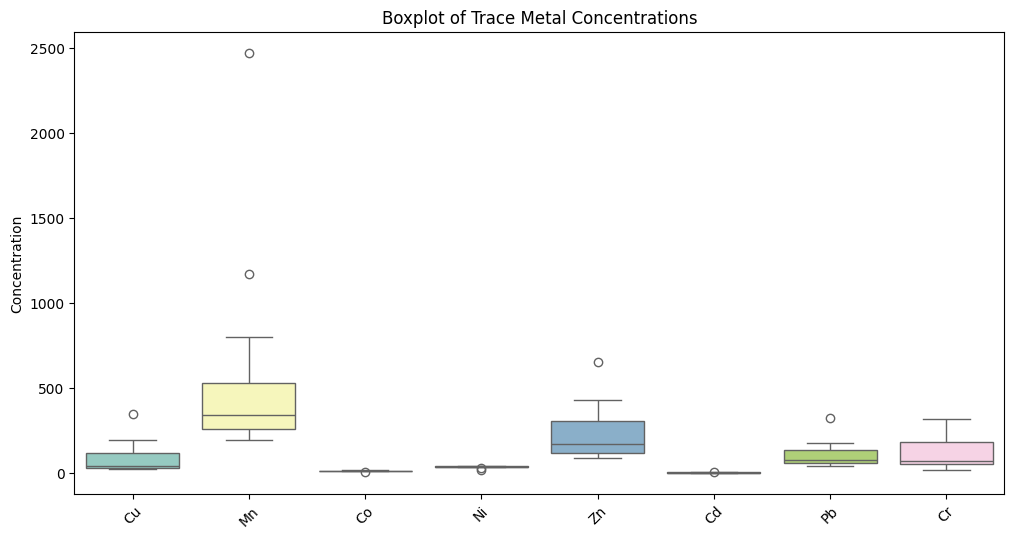

In [26]:
# Boxplot to visualize outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[trace_metals], palette='Set3')
plt.title('Boxplot of Trace Metal Concentrations')
plt.ylabel('Concentration')
plt.xticks(rotation=45)
plt.show()

General Patterns:
Mn dominates in terms of concentration variability and extreme values, potentially indicating localized environmental contamination or distinct geochemical behavior.
Zn, Pb, and Cr show moderate variability, hinting at common sources but less dramatic spatial variation compared to Mn.
Cu, Co, Ni, and Cd are relatively consistent and occur at low levels across sites.
Implications:
High variability in metals like Mn and Zn might suggest anthropogenic inputs, such as industrial discharges or localized pollution hotspots.
The presence of outliers highlights the need for further investigation into specific locations where these elevated concentrations occur.

In [42]:
# Loop over each metal column to detect and handle outliers
for metal in trace_metals:
    Q1 = data[metal].quantile(0.25)  # 25th percentile
    Q3 = data[metal].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers at the boundaries for each metal
    data[metal] = np.where(data[metal] < lower_bound, lower_bound,
                           np.where(data[metal] > upper_bound, upper_bound, data[metal]))


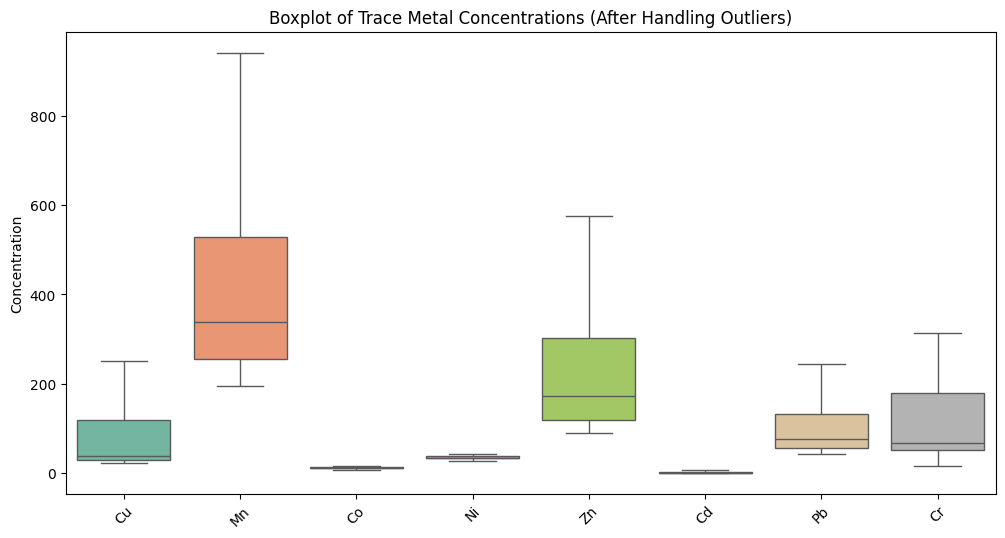

In [44]:
# Verify results with boxplot after handling outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=data[trace_metals], palette='Set2')
plt.title('Boxplot of Trace Metal Concentrations (After Handling Outliers)')
plt.ylabel('Concentration')
plt.xticks(rotation=45)
plt.show()

### Step 6 - Clustering

### Feature Selection and Scaling

In [47]:
# Step 1: Select the features
features = ['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', 'Total Biomass']
data_subset = data[features]

In [48]:
# Step 2: Scale the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_subset)


### K-Means Clustering

In [255]:
# Determine the Optimal Number of Clusters (Elbow Method)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)
    warnings.filterwarnings('ignore')

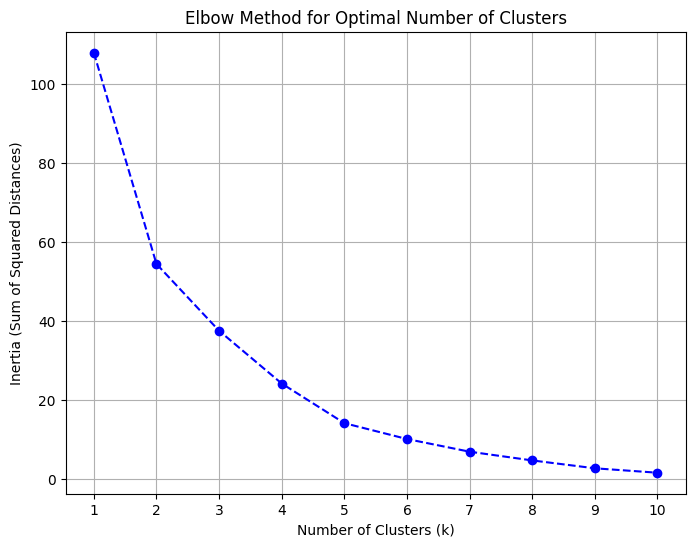

In [65]:
# Plotting the Elbow Method graph to determine the optimal k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [176]:
#  Apply K-means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # You can change the number of clusters as needed
labels = kmeans.fit_predict(data_scaled)

# Add the KMeans cluster labels to the dataset
data['Kmeans_Cluster'] = labels

C:\Users\Ankush Ahuja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Ankush Ahuja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [140]:
# Function to visualize clustering results
def plot_clusters(X, labels, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis', legend='full')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(title="Cluster")
    plt.show()

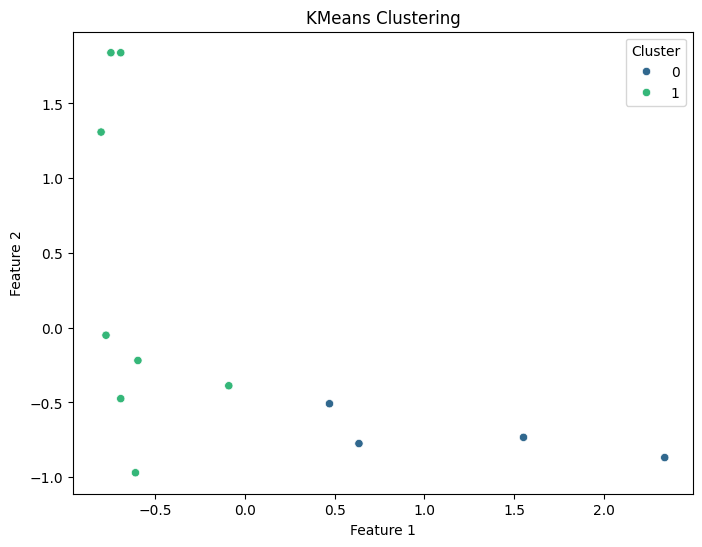

In [78]:
# Plot KMeans clusters
plot_clusters(data_scaled, kmeans_labels, "KMeans Clustering")

In [180]:
# Analyze the Clusters
cluster_summary = data.groupby('Kmeans_Cluster').mean(numeric_only=True)

In [181]:
# Print the cluster summary to view the mean values for each feature within each cluster
print("Cluster Summary (Mean of each feature for every cluster):")
print(cluster_summary)

Cluster Summary (Mean of each feature for every cluster):
                Abra alba  Abra nitida  Abra sp.  Amaeana trilobata  \
Kmeans_Cluster                                                        
0                   28.25        0.000       0.0              0.750   
1                   36.25        4.875       0.0              9.125   

                Ampharete grubei  Amphipoda sp. indet.  Amphitritinae  \
Kmeans_Cluster                                                          
0                          0.750                   0.0            0.0   
1                          0.375                   0.0            0.0   

                Amphiura chiajei  Amphiura filiformis  Amphiura sp.  ...  \
Kmeans_Cluster                                                       ...   
0                          0.000                  0.0          0.00  ...   
1                         36.375                  9.5          0.25  ...   

                     Zn      Cd         Pb      Cr    Dep  

In [246]:
# List of selected columns
selected_columns = ['Cu', 'Mn', 'Co', 'Ni', 'Zn','Cd', 'Pb', 'Cr', 'Dep', '%C', '%N', 'Species Diversity', 
                    'Total Biomass']

# Group by clusters and calculate mean for the selected columns
cluster_summary = data.groupby('Kmeans_Cluster')[selected_columns].mean()

# Print the cluster summary
print("Cluster Summary for Selected Columns:")
print(cluster_summary)

Cluster Summary for Selected Columns:
                     Cu         Mn      Co        Ni       Zn      Cd  \
Kmeans_Cluster                                                          
0               171.875  260.25000  10.250  35.25000  405.250  3.3625   
1                34.875  548.46875  11.875  33.09375  144.875  0.1875   

                       Pb      Cr    Dep      %C     %N  Species Diversity  \
Kmeans_Cluster                                                               
0               171.65625  225.00   84.5  7.6750  0.765              10.75   
1                62.87500   56.75  106.5  2.7625  0.410              21.50   

                Total Biomass  
Kmeans_Cluster                 
0                    1037.000  
1                     633.625  


Cluster 0:
Represents areas with high contamination (heavy metals), richer organic content, and lower species diversity but higher biomass. This could be indicative of stressed ecosystems where certain species dominate.

Cluster 1:
Represents cleaner areas with higher species diversity, lower heavy metal contamination, but lower organic content and biomass, possibly indicating less stressed and more balanced ecological conditions.



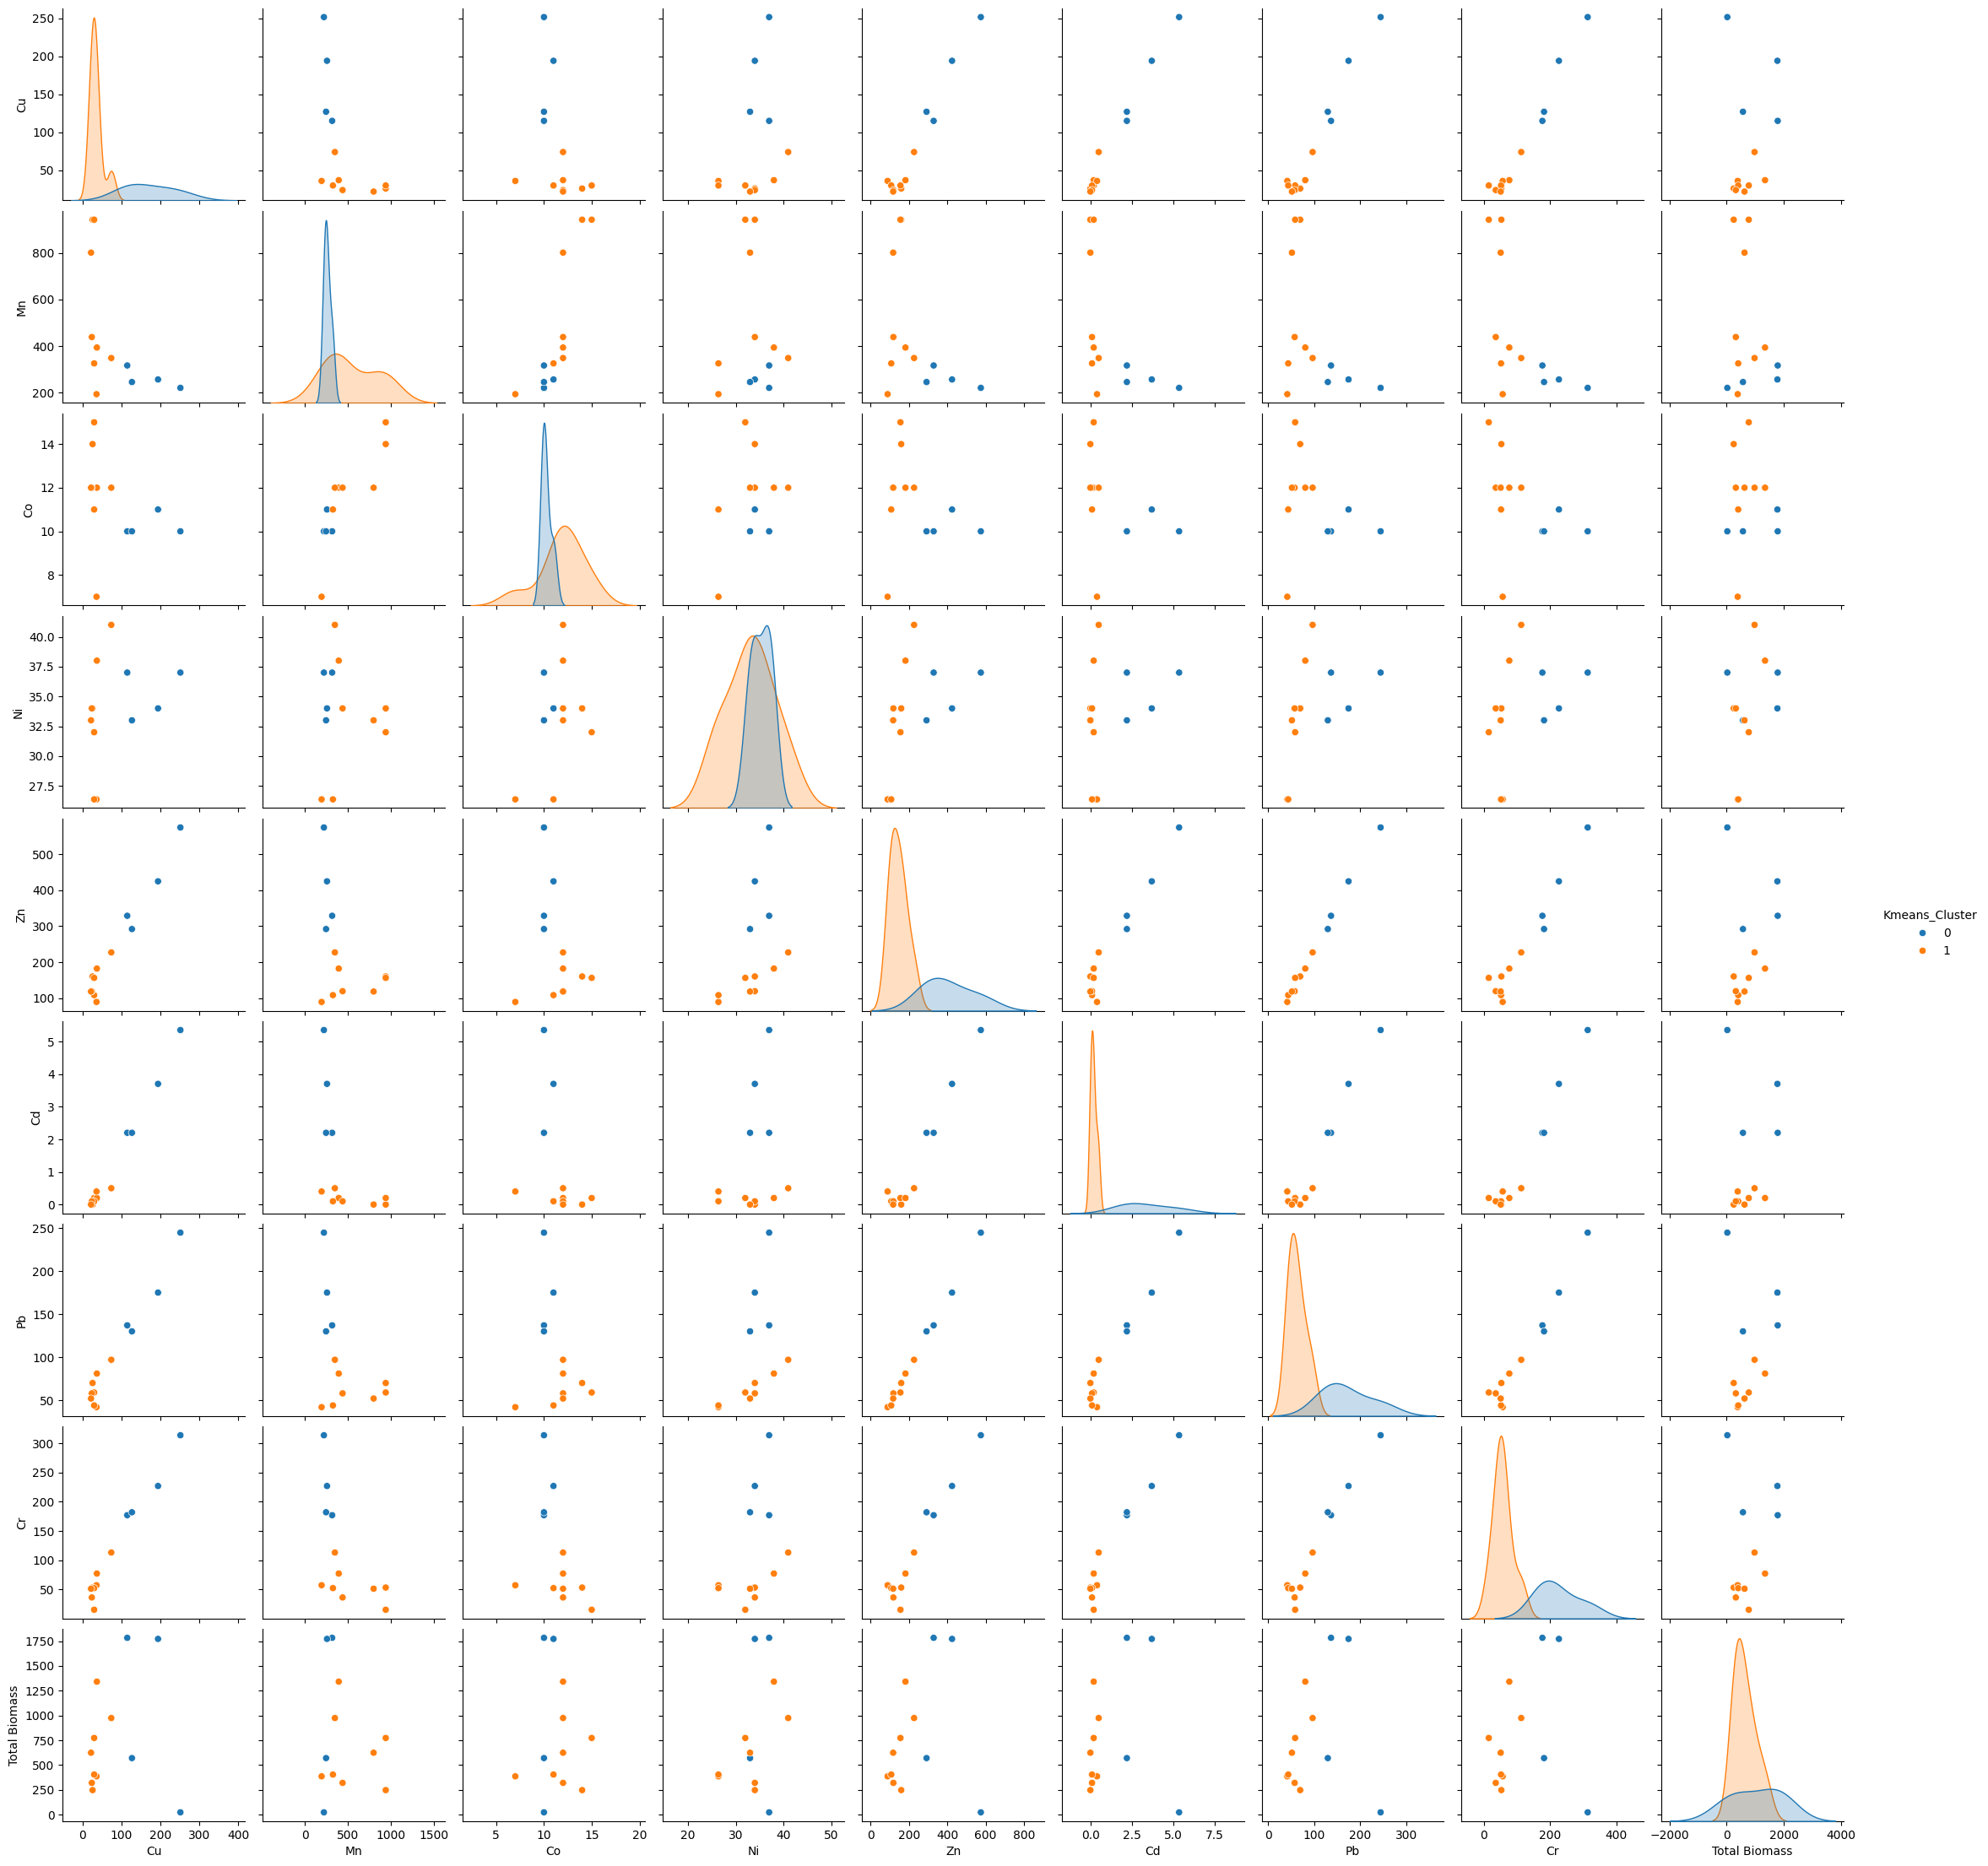

In [182]:
# Create a pairplot with the 'Kmeans_Cluster' as the hue
sns.pairplot(data[['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', 'Total Biomass', 'Kmeans_Cluster']], hue='Kmeans_Cluster')
plt.show()

Heavy Metals (Cu, Mn, Zn, etc.):

Positive correlations are observed between certain heavy metals (e.g., Cu vs. Zn, Mn vs. Cd), particularly in Cluster 0 (Blue). This indicates a shared source or similar environmental process contributing to their accumulation.
In Cluster 1, these relationships are weaker or more scattered, suggesting less contamination and possibly more varied environmental factors.
Species Diversity vs. Heavy Metals:

Cluster 0: Lower species diversity is associated with higher concentrations of heavy metals, indicating that contamination negatively impacts biodiversity.
Cluster 1: Higher species diversity aligns with lower contamination levels, reflecting healthier ecosystems.
Soil Properties (%C, %N) vs. Biomass:

Positive relationships between %C, %N, and Total Biomass are evident in both clusters.
Cluster 0: These relationships are tighter, suggesting that organic-rich soils support higher biomass even in contaminated conditions.
Cluster 1: The relationships are more spread out, likely due to cleaner conditions with lower biomass variability.


Overall Insights:
Cluster 0 (Blue):
Heavily contaminated regions with high heavy metal concentrations.
Lower species diversity but higher biomass, likely dominated by a few tolerant species.
Richer in organic content, as shown by higher %C and %N.

Cluster 1 (Orange):
Cleaner regions with lower contamination levels.
Higher species diversity but lower total biomass, indicating a healthier and more balanced ecosystem.
Lower organic content in the soil.

In [152]:
silhouette_avg = silhouette_score(data_scaled, labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.3806261155656456


A score of 0.38 indicates that the clusters are moderately distinct, with data points generally closer to their own cluster centroids than to others. However, some overlap between clusters is present, suggesting that the separation is not entirely clear. The clustering captures some meaningful structure in the data, as seen in the differences across heavy metal concentrations, biodiversity, and other features, but there is room for improvement in defining the cluster boundaries. 

In [256]:
# Cross-tabulation with an external categorical variable
external_category = data['Site']
cross_tab = pd.crosstab(cluster_labels, external_category, rownames=['Kmeans_Cluster'], colnames=['External Category'])
print(cross_tab)


External Category  S1  S10  S11  S12  S2  S3  S4  S5  S6  S7  S8  S9
Kmeans_Cluster                                                      
0                   1    1    1    1   1   1   1   0   0   0   0   1
1                   0    0    0    0   0   0   0   1   1   1   1   0


Cluster 0:
Contains S1, S10, S11, S12, S2, S3, S4, and S9 (indicated by 1 in Cluster 0).
Cluster 1:
Contains S5, S6, S7, and S8 (indicated by 1 in Cluster 1).

# Mini Batch KMeans

In [82]:
# Apply MiniBatchKMeans
mini_kmeans = MiniBatchKMeans(n_clusters=2, random_state=42, batch_size=100)
mini_kmeans_labels = mini_kmeans.fit_predict(data_scaled)
mini_kmeans_silhouette = silhouette_score(data_scaled, mini_kmeans_labels)
print(f"Mini Batch KMeans Silhouette Score: {mini_kmeans_silhouette:.2f}")

C:\Users\Ankush Ahuja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Ankush Ahuja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1902: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 2048 or by setting the environment variable OMP_NUM_THREADS=1
  warnings.warn(


Mini Batch KMeans Silhouette Score: 0.38


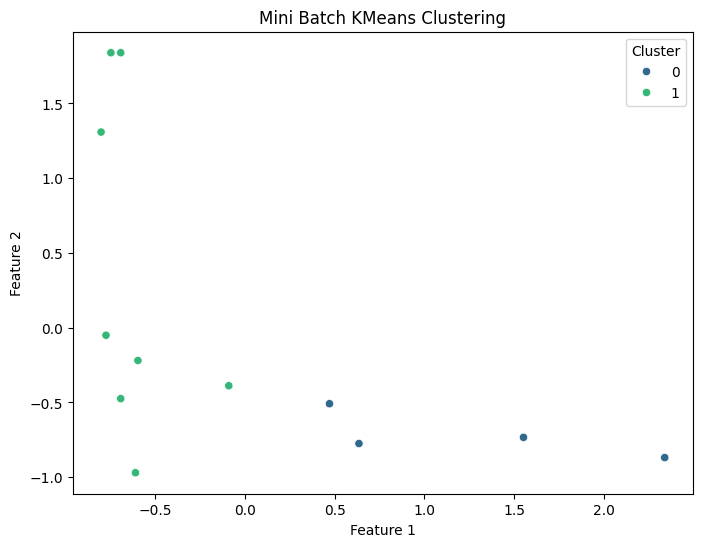

In [84]:
# Plot MiniBatchKMeans clusters
plot_clusters(data_scaled, mini_kmeans_labels, "Mini Batch KMeans Clustering")

### Hierarchial Clustering

In [98]:
# Step 1: Compute the linkage matrix
linked = linkage(data_scaled, method='ward')

# Show a snippet of the linkage matrix
print(linked[:5])  # Show the first 5 rows of the linkage matrix

[[ 0.          1.          1.26841408  2.        ]
 [ 2.          3.          1.26938304  2.        ]
 [10.         11.          1.49763661  2.        ]
 [ 4.          6.          1.99677477  2.        ]
 [ 8.          9.          2.10278502  2.        ]]


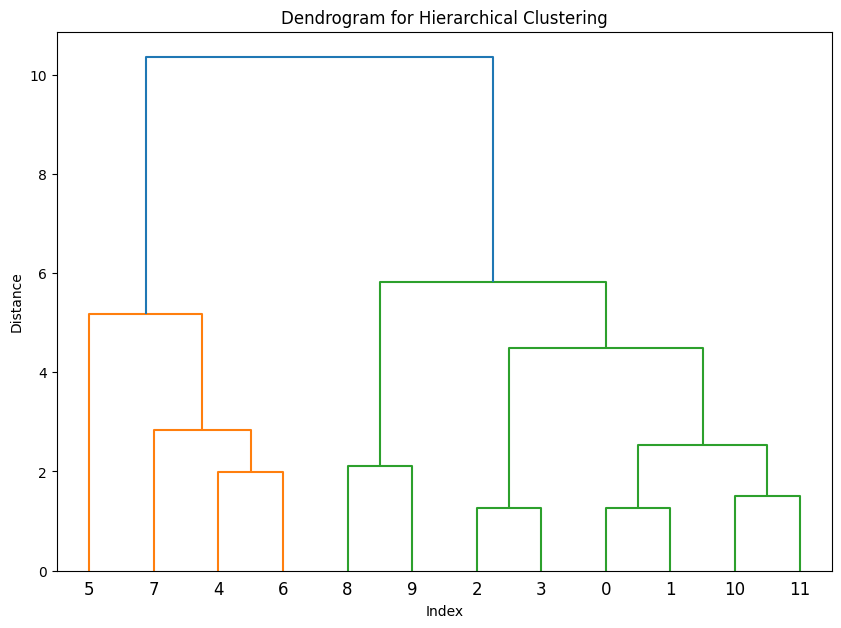

In [99]:
# Step 2: Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Index")
plt.ylabel("Distance")
plt.show()

The plot clearly reveals two main clusters (depicted in blue), each further subdivided into smaller subclusters. 

In [102]:
# Step 3: Form clusters by cutting the dendrogram at a certain distance
max_d = 6  # 
cluster_labels = fcluster(linked, max_d, criterion='distance')

# Show the cluster labels
print(cluster_labels)

[2 2 2 2 1 1 1 1 2 2 2 2]


In [104]:
# Step 4: Calculate the silhouette score for the clustering
silhouette_avg = silhouette_score(data_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.3f}")

Silhouette Score: 0.381


A score of 0.38 indicates that the clusters are moderately distinct, with data points generally closer to their own cluster centroids than to others. However, some overlap between clusters is present, suggesting that the separation is not entirely clear. The clustering captures some meaningful structure in the data, as seen in the differences across heavy metal concentrations, biodiversity, and other features, but there is room for improvement in defining the cluster boundaries.

In [105]:
# Step 5: Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)


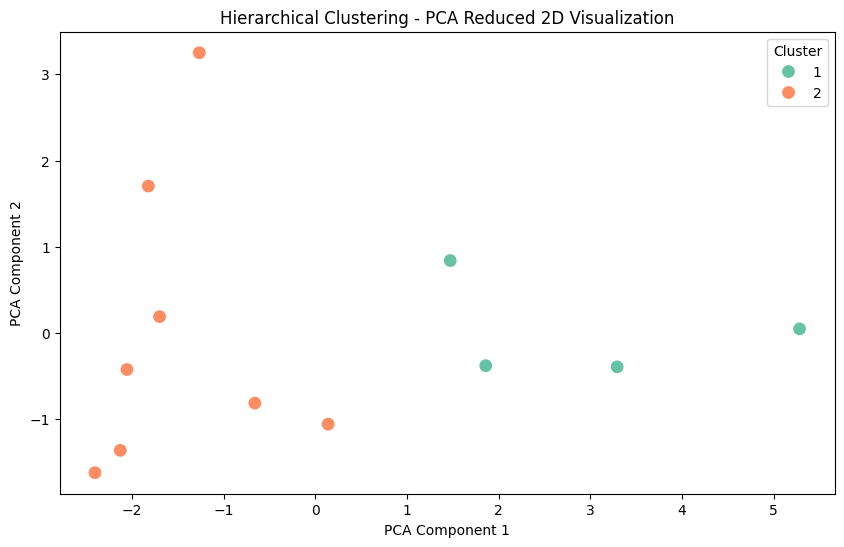

In [106]:
# Visualize the clusters in the reduced 2D PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=cluster_labels, palette='Set2', s=100)
plt.title("Hierarchical Clustering - PCA Reduced 2D Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster", loc='upper right')
plt.show()

In [108]:
# Step 6: Calculate the silhouette score for the clustering in PCA space
silhouette_avg = silhouette_score(data_pca, cluster_labels)
print(f"Silhouette Score (PCA Reduced): {silhouette_avg:.3f}")

Silhouette Score (PCA Reduced): 0.485


n the context of PCA-reduced space, this score reflects how well the clustering algorithm has separated the data after reducing the dimensionality using PCA. a value of 0.485 shows that the clustering works moderately well, and has improved after PCA. 

In [252]:
# Step 7: Analyze the cluster Summary


# Add cluster labels to the data
data_subset = data[['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', 'Total Biomass']].copy()
data_subset['Cluster'] = cluster_labels

# 1. Number of data points per cluster
cluster_counts = data_subset['Cluster'].value_counts().sort_index()

# 2. Cluster centers (mean of each feature in each cluster)
cluster_means = data_subset.groupby('Cluster').mean()

# 3. Silhouette score for each cluster
silhouette_vals = silhouette_samples(data_scaled, cluster_labels)
data_subset['Silhouette Score'] = silhouette_vals

cluster_summary = data_subset.groupby('Cluster').agg({
    'Cu': ['mean', 'median'],
    'Mn': ['mean', 'median'],
    'Co': ['mean', 'median'],
    'Ni': ['mean', 'median'],
    'Zn': ['mean', 'median'],
    'Cd': ['mean', 'median'],
    'Pb': ['mean', 'median'],
    'Cr': ['mean', 'median'],
    'Total Biomass': ['mean', 'median'],
    'Silhouette Score': ['mean']
})

# Print the cluster summary
print("Cluster Counts:\n", cluster_counts)
print("\nCluster Means:\n", cluster_means)
print("\nCluster Summary:\n", cluster_summary)

# Add cluster labels to the dataset
data['Cluster'] = cluster_labels

# Print the first few rows of the dataset with the cluster labels
print("\nDataset with Cluster Labels:\n", data.head())


Cluster Counts:
 Cluster
0    8
1    4
Name: count, dtype: int64

Cluster Means:
               Cu         Mn      Co        Ni       Zn      Cd         Pb  \
Cluster                                                                     
0         34.875  548.46875  11.875  33.09375  144.875  0.1875   62.87500   
1        171.875  260.25000  10.250  35.25000  405.250  3.3625  171.65625   

             Cr  Total Biomass  
Cluster                         
0         56.75        633.625  
1        225.00       1037.000  

Cluster Summary:
               Cu                Mn             Co               Ni         \
            mean median       mean median    mean median      mean median   
Cluster                                                                     
0         34.875   30.0  548.46875  416.5  11.875   12.0  33.09375   33.5   
1        171.875  160.5  260.25000  251.5  10.250   10.0  35.25000   35.5   

              Zn             Cd                Pb             Cr        


Cluster 0: 8 samples (equal to cluster 1 in Kmeans)
Lower values for most elements (e.g., Cu, Zn, Pb, Cd) compared to Cluster 1.
Lower Total Biomass: The mean biomass is 633.625 for Cluster 0, suggesting a lower ecological richness or less biological activity.
Cluster 1: 4 samples  9 equal to cluster 0 in Kmeana)
Higher values for metals like Cu, Zn, and Pb, as well as higher Total Biomass (1037.000).
Cluster 1 could be associated with sites that have higher contamination or richer ecological activity due to the higher biomass.

Silhouette Score:The silhouette scores indicate that Cluster 0 is more distinct compared to Cluster 1. Cluster 0 has a higher silhouette score, suggesting its members are better grouped, while Cluster 1 may have some degree of uncertainty in the cluster membership.

Interpretation of the Clusters:
Cluster 0 likely represents sites with lower contamination or more ecologically balanced environments. These sites have lower levels of metals like Cu, Zn, and Pb but relatively higher levels of Mn and Co, which could suggest specific environmental conditions or pollutant patterns.
Cluster 0 also has higher species diversity, indicating more ecological richness or less environmental stress.
Cluster 1 seems to correspond to sites with higher contamination or pollution levels, as indicated by the higher concentrations of Cu, Zn, Pb, and Cd, and also the higher total biomass. The higher biomass might be due to specific organisms thriving in these conditions (e.g., pollution-tolerant species).
Cluster 1 shows lower species diversity, which could indicate a less diverse ecosystem, possibly due to the high levels of contaminants reducing habitat diversity.

### Agglomerative clustering 

In [163]:
# Step 2: Apply Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=2)  # You can change the number of clusters
cluster_labels = agg_clust.fit_predict(data_scaled)


# Step 5: Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=2)  # Change n_clusters as needed
agg_labels = agg_clustering.fit_predict(data_scaled)

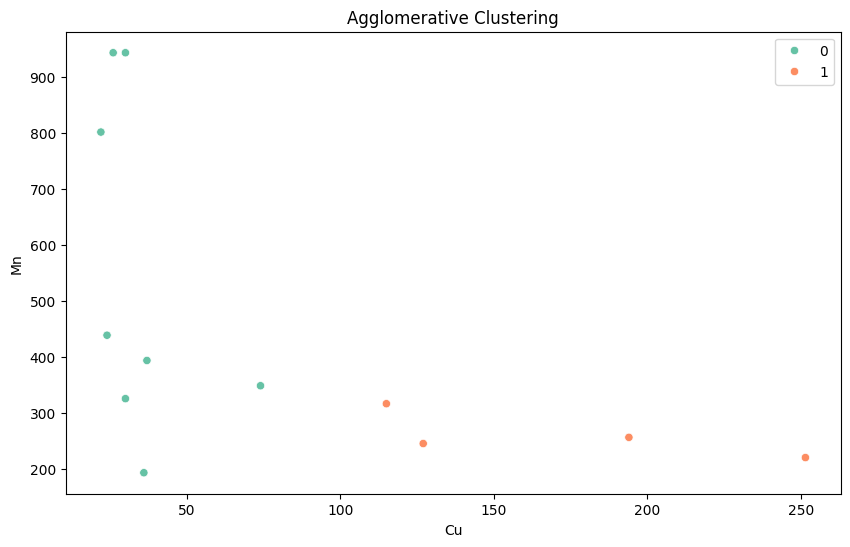

In [164]:
# Visualizing the KMeans, Hierarchical, and Agglomerative results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Cu'], y=data['Mn'], hue=agg_labels, palette="Set2")
plt.title('Agglomerative Clustering')
plt.show()

In [165]:
# Step 3: Calculate Silhouette Score
sil_score = silhouette_score(data_scaled, agg_labels)
print(f"Silhouette Score for Agglomerative Clustering: {sil_score}")

Silhouette Score for Agglomerative Clustering: 0.3806261155656456


In [166]:
# Step 3: Add cluster labels to the dataset
data['Agglomerative_Cluster'] = agg_labels

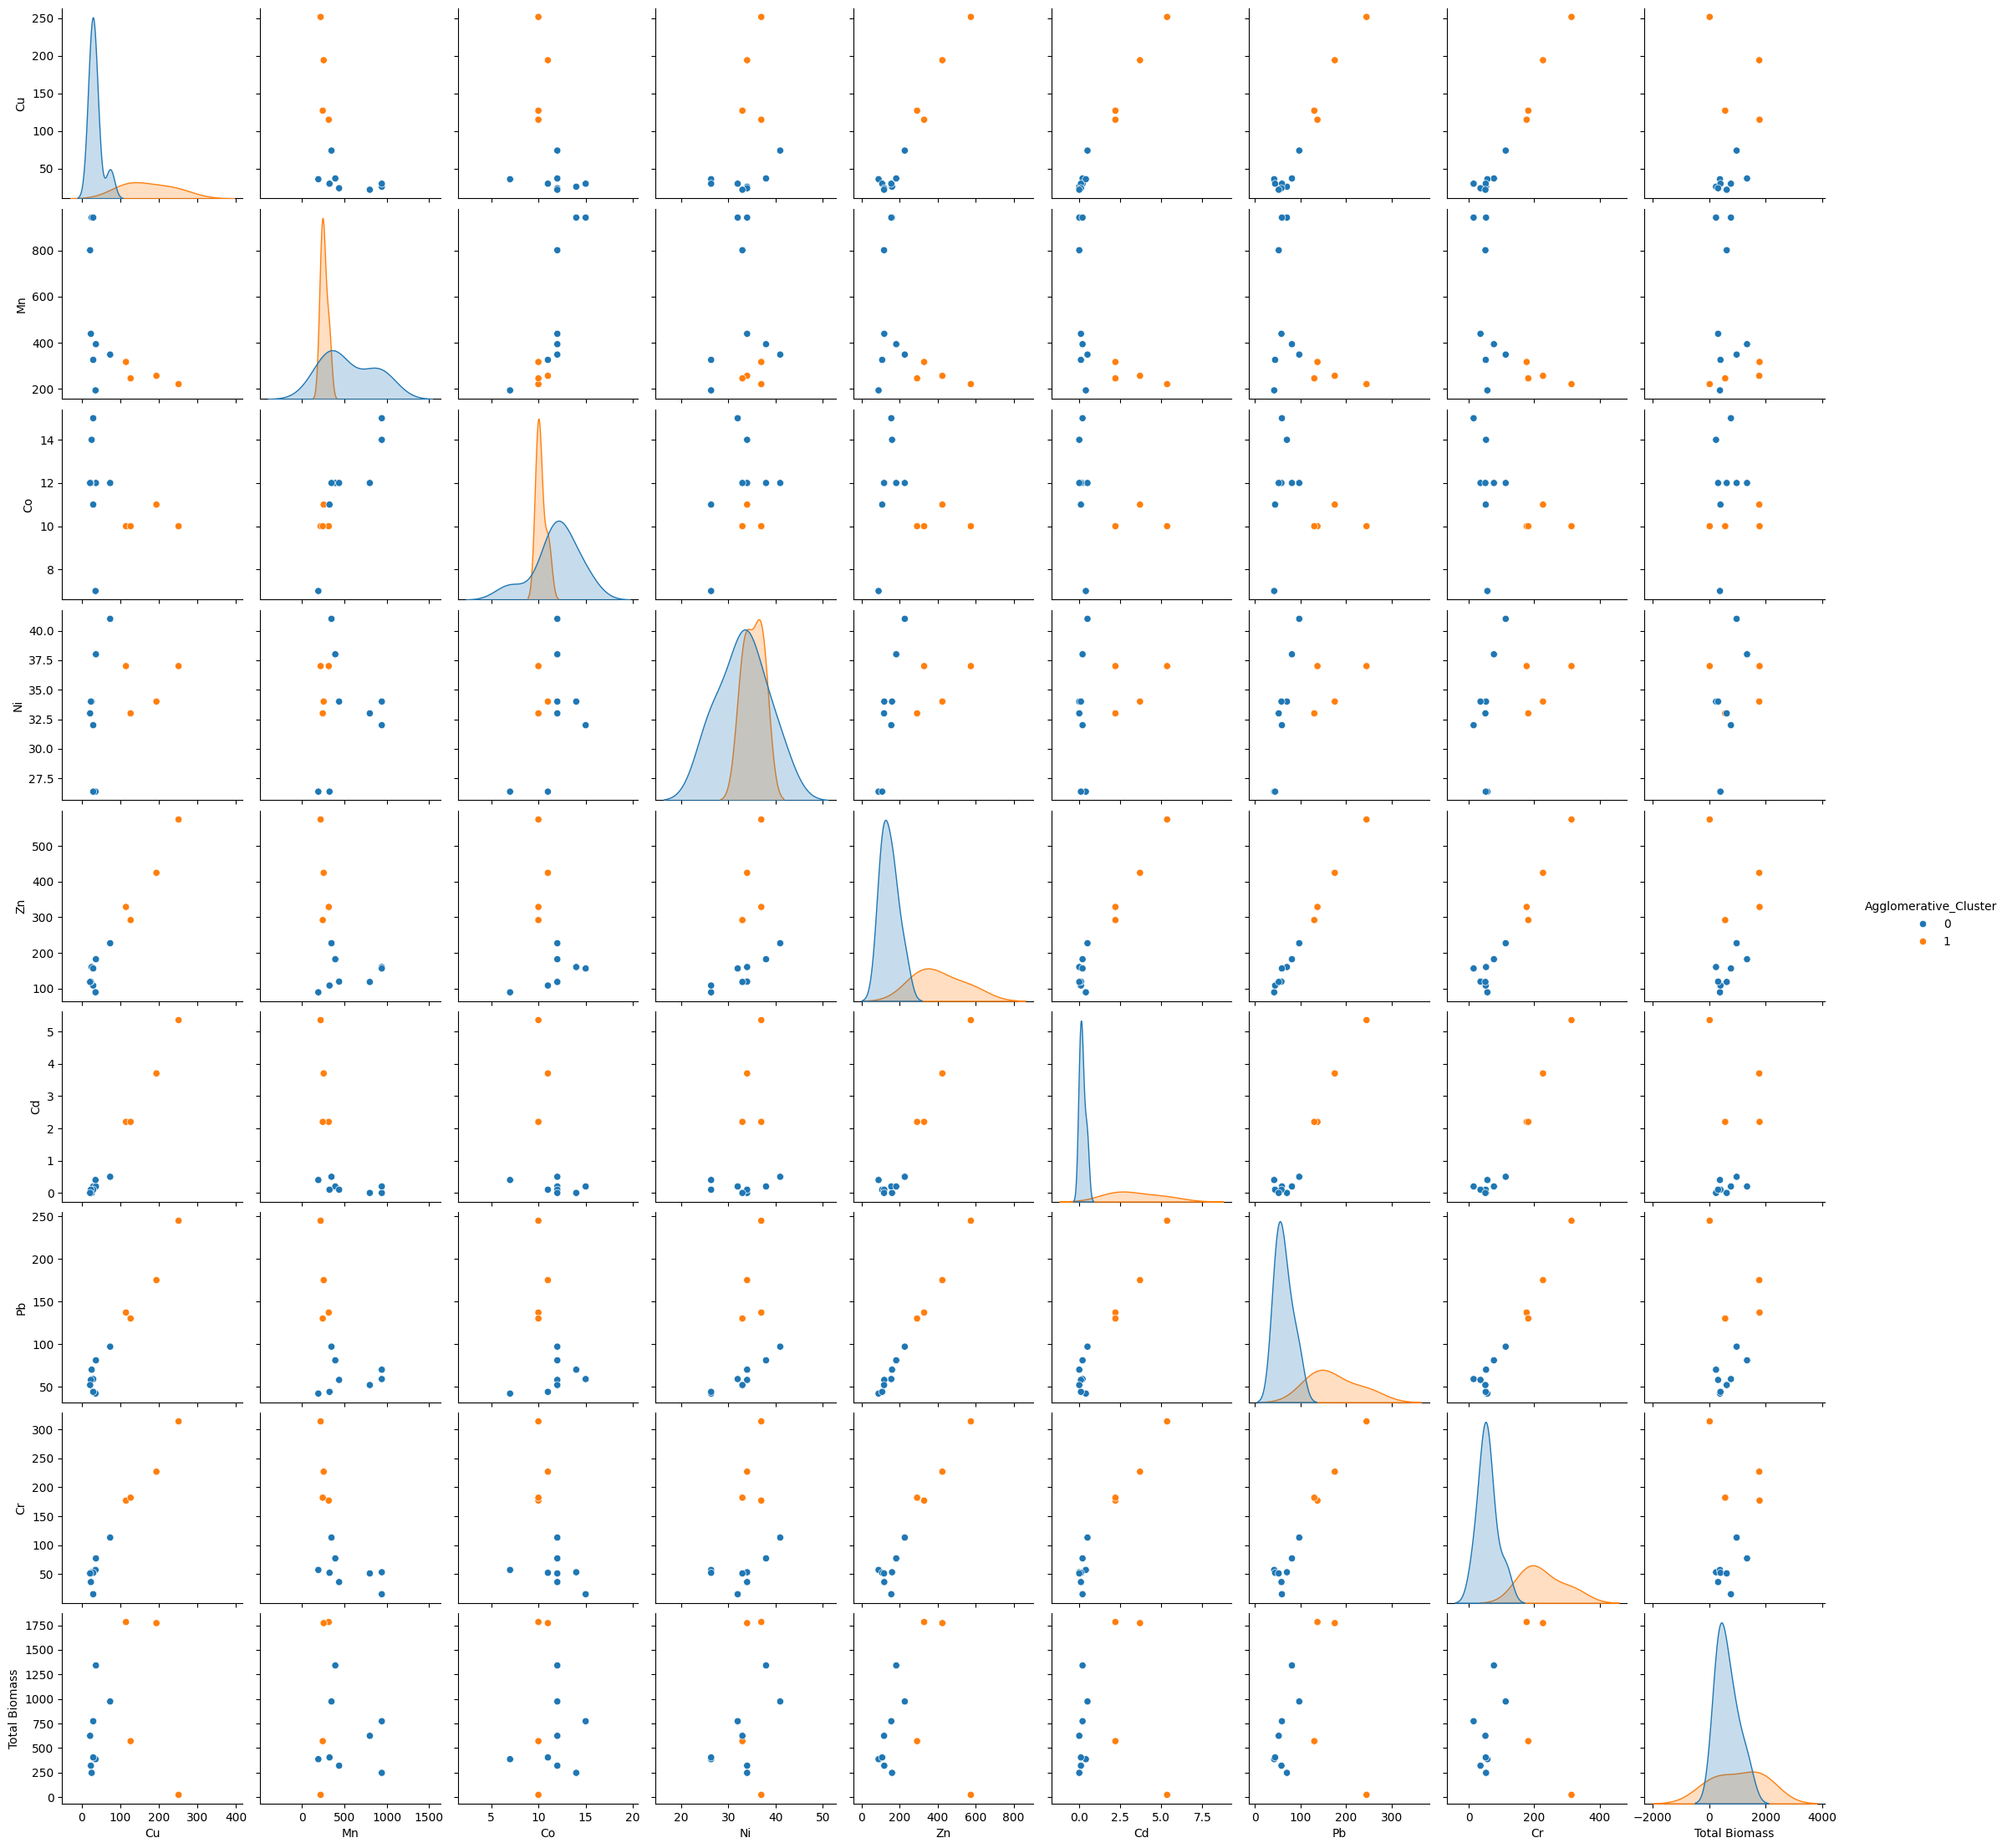

In [154]:
# Step 4: Visualize the clusters
sns.pairplot(data[['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', 'Total Biomass', 'Agglomerative_Cluster']], hue='Agglomerative_Cluster')
plt.show()

1. Heavy Metals Correlations (Cu, Mn, Zn, etc.):
Cluster 0 (Blue):
The pairplot likely shows strong positive correlations between some heavy metals in this cluster (e.g., Cu vs. Zn, Mn vs. Cd). These tight relationships suggest that heavy metals share a common source, such as industrial pollution or similar geochemical pathways.
Cluster 1 (Orange):
In this cluster, scatter points are more dispersed, reflecting weaker or inconsistent relationships between heavy metals. This indicates cleaner conditions with reduced heavy metal accumulation, likely due to varied environmental influences.
2. Species Diversity vs. Heavy Metals:
Cluster 0 (Blue):
If diversity-related variables are included, the plot would likely show an inverse relationship between species diversity and heavy metal concentrations. This suggests that contamination from heavy metals suppresses biodiversity, leaving only species that can tolerate such conditions.
Cluster 1 (Orange):
A positive association between diversity and low heavy metal concentrations may be observed. This reflects healthier ecosystems where species thrive due to reduced contamination.
3. Soil Properties (%C, %N) vs. Biomass:
Cluster 0 (Blue):
The pairplot might show strong positive correlations between %C, %N, and total biomass in this cluster, even under contaminated conditions. This suggests that organic-rich soils can still support biomass, possibly dominated by species that tolerate pollution.
Cluster 1 (Orange):
The relationships are expected to be weaker and more dispersed, reflecting more natural variability in cleaner ecosystems. This suggests that biomass in cleaner conditions is less dependent on organic soil content.
4. Overall Insights:
Cluster 0 (Blue):
The scatterplots suggest this cluster is characterized by high heavy metal concentrations, lower diversity, and higher biomass. The relationships between variables are more structured, indicating consistent contamination impacts.
Cluster 1 (Orange):
The scatterplots show more dispersed patterns for many variables, supporting the interpretation of cleaner, less contaminated conditions. Higher species diversity and lower biomass align with a healthier ecosystem.

### Step 7: Predictive Modeling

### Linear Regression Model

In [202]:
# Step 1: Prepare features (X) and target variable (y)
features = ['Cu', 'Mn', 'Co', 'Ni', 'Zn', 'Cd', 'Pb', 'Cr', '%C', '%N', 'Dep']  # Add new features
X = data[features]
y = data['Species Diversity']

In [203]:
# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [204]:
# Step 3: Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [205]:
# Step 4: Train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)


LinearRegression()

In [206]:
# Step 5: Predict and evaluate
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Display results
print("Linear Regression Model Evaluation (After Adding New Features and Normalization):")
print(f"R-squared (R²): {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")


Linear Regression Model Evaluation (After Adding New Features and Normalization):
R-squared (R²): -1.46
Mean Absolute Error (MAE): 9.78
Mean Squared Error (MSE): 95.78


R-squared (R² = -1.46):
The Linear Regression model has a negative R², indicating that it predicts worse than using the mean of the target variable. This suggests that the model has not captured any meaningful patterns in the data, leading to poor performance.

Mean Absolute Error (MAE = 9.78):
The average prediction error is 9.78, meaning the model’s predictions are off by 9.78 units on average. This error is significant, indicating poor model fit despite the addition of new features and normalization.

Mean Squared Error (MSE = 95.78):
The squared prediction errors are high at 95.78, further confirming that the model is not performing well and making large prediction errors.

Despite adding new features and normalizing the data, the Linear Regression model remains poorly fitted, with a negative R² (-1.46) and high prediction errors (MAE: 9.78, MSE: 95.78). This suggests issues such as irrelevant features, poor model choice, or a mismatch between the model and data. Further feature engineering, model exploration, or data preprocessing is required for improvement.

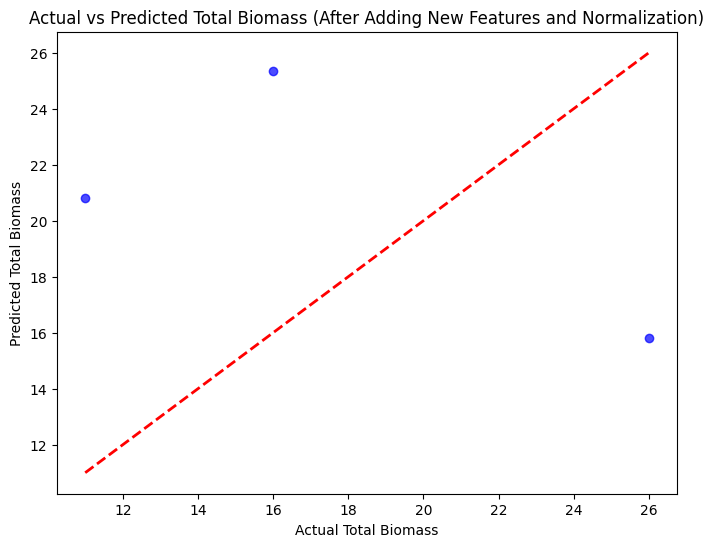

In [207]:
# Step 6: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (After Adding New Features and Normalization)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

Model Performance:

Significant deviations from the red line suggest that the model struggles to predict Total Biomass accurately.
The blue points being scattered above or below the red line reflect both under-prediction and over-prediction issues.

The large errors between actual and predicted values, combined with the earlier metrics (e.g., negative R²), confirm that the model is poorly fitted.

### Random Forest Regressor

In [208]:
# Initialize the model
rf_model = RandomForestRegressor(random_state=42)


In [209]:
# Step 1: Train the model
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [210]:
# Step 2: Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [211]:
# Step 3: Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Display results
print("Random Forest Model Evaluation:")
print(f"R-squared (R²): {r2_rf:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")

Random Forest Model Evaluation:
R-squared (R²): -1.15
Mean Absolute Error (MAE): 8.37
Mean Squared Error (MSE): 83.57


Interpretation:
R-squared (R² = -1.15): The model performs worse than a simple mean prediction, indicating poor fit to the data.
Mean Absolute Error (MAE = 8.37): The average prediction error is 8.37 units, suggesting moderate errors, but this depends on the scale of the target variable.
Mean Squared Error (MSE = 83.57): High MSE reflects large prediction errors, with squared terms emphasizing the impact of outliers.

The Random Forest model also performs poorly, with a negative R² indicating it fails to explain the variance in the target variable. High error metrics suggest issues with data quality, feature selection, or insufficient model tuning. Further investigation of feature relevance, hyperparameter optimization, or alternative models is needed.

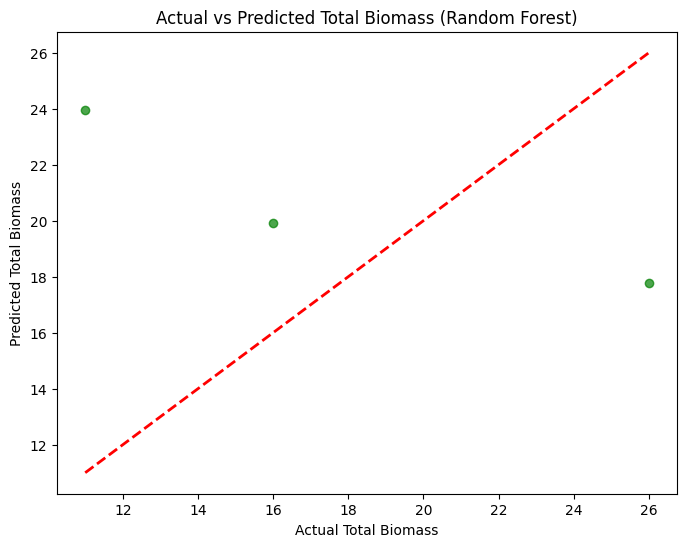

In [213]:
# Step 4: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (Random Forest)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

Hyperparameter Tunning

In [215]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Min samples in leaf
    'max_features': ['auto', 'sqrt', 'log2']  # Features to consider for splitting
}

# Initialize the Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the best model
best_rf_model = grid_search.best_estimator_

Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [216]:
# Step 1: Make predictions
y_pred_rf = best_rf_model.predict(X_test_scaled)

# Step 2: Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Display results
print("Tuned Random Forest Model Evaluation:")
print(f"R-squared (R²): {r2_rf:.2f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")


Tuned Random Forest Model Evaluation:
R-squared (R²): -1.05
Mean Absolute Error (MAE): 8.14
Mean Squared Error (MSE): 79.71


Interpretation:
R-squared (R² = -1.05):

The tuned Random Forest model still has a negative R², indicating that it predicts worse than using the mean of the target variable. However, the performance has slightly improved compared to the untuned model (-1.15).
Mean Absolute Error (MAE = 8.14):

The average prediction error has decreased slightly from 8.37 to 8.14, showing marginal improvement in prediction accuracy.
Mean Squared Error (MSE = 79.71):

The squared prediction errors have also slightly reduced from 83.57 to 79.71, reflecting modest gains from hyperparameter tuning.


Despite hyperparameter tuning, the Random Forest model remains poorly fitted, with a slightly improved R² (-1.05) and reduced errors (MAE: 8.14, MSE: 79.71). This suggests deeper issues such as noisy or irrelevant features, insufficient data, or a mismatch between the model and the data structure. Further feature engineering, data preprocessing, or trying alternative models might be necessary for significant improvement.

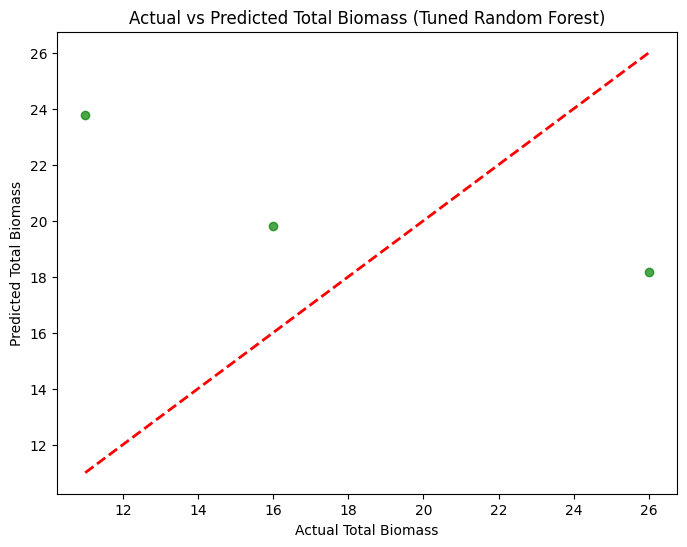

In [217]:
# Step 3: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, color='green', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (Tuned Random Forest)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

### Gradient Boosting Regressor

In [219]:
# Initialize the model
gb_model = GradientBoostingRegressor(random_state=42)


In [220]:
# Step 1: Train the model
gb_model.fit(X_train_scaled, y_train)

GradientBoostingRegressor(random_state=42)

In [221]:
# Step 2: Make predictions
y_pred_gb = gb_model.predict(X_test_scaled)

In [222]:
# Step 3: Evaluate the model
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)

# Display results
print("Gradient Boosting Model Evaluation:")
print(f"R-squared (R²): {r2_gb:.2f}")
print(f"Mean Absolute Error (MAE): {mae_gb:.2f}")
print(f"Mean Squared Error (MSE): {mse_gb:.2f}")

Gradient Boosting Model Evaluation:
R-squared (R²): -1.14
Mean Absolute Error (MAE): 7.79
Mean Squared Error (MSE): 83.22


Interpretation:
R-squared (R² = -1.14):

A negative R² indicates that the model is performing worse than a baseline model that predicts the mean of the target variable. The model is not effectively capturing the relationship between features and the target variable.
Mean Absolute Error (MAE = 7.79):

The average prediction error is slightly lower than previous models (e.g., Random Forest), suggesting some improvement in prediction accuracy but still substantial errors.
Mean Squared Error (MSE = 83.22):

The MSE is slightly better than the untuned Random Forest model (83.57), but the overall error remains high, highlighting significant prediction discrepancies.

The Gradient Boosting model performs slightly better than the untuned Random Forest model (lower MAE and MSE) but still has a negative R² (-1.14), indicating poor predictive performance. The results suggest persistent underlying issues, such as irrelevant features, data quality problems, or the need for more advanced feature engineering. Alternative strategies, such as further tuning, feature selection, or exploring data transformations, are recommended.


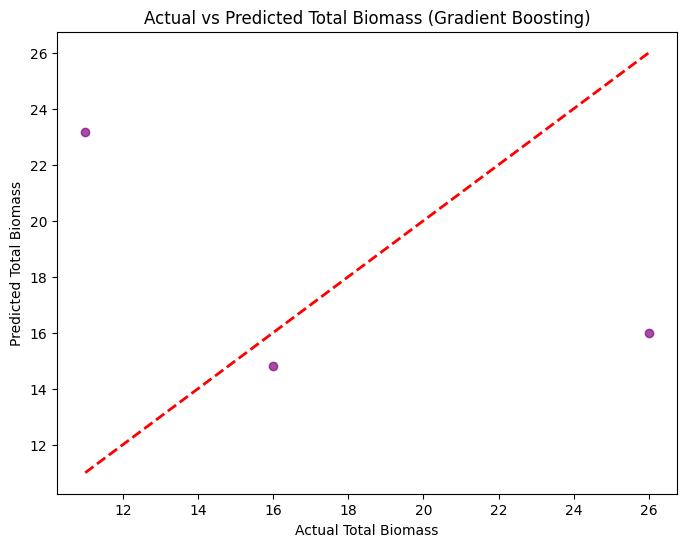

In [223]:
# Step 4: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gb, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (Gradient Boosting)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

### Support Vector Regressor (SVR)

In [225]:
# Initialize the SVR model
svr_model = SVR()

In [226]:
# Step 1: Train the model
svr_model.fit(X_train_scaled, y_train)


SVR()

In [227]:
# Step 2: Make predictions
y_pred_svr = svr_model.predict(X_test_scaled)

In [229]:
# Step 3: Evaluate the model
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)

# Display results
print("Support Vector Regressor Model Evaluation:")
print(f"R-squared (R²): {r2_svr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")

Support Vector Regressor Model Evaluation:
R-squared (R²): -0.19
Mean Absolute Error (MAE): 5.64
Mean Squared Error (MSE): 46.21


Interpretation:
R-squared (R² = -0.19):

The SVR model performs slightly better than previous models, as the R² is closer to zero (though still negative). A negative R² means the model is still performing worse than a simple mean prediction but is an improvement over other approaches like Random Forest and Gradient Boosting.
Mean Absolute Error (MAE = 5.64):

The MAE indicates an average prediction error of 5.64, which is notably lower than previous models. This suggests that the SVR model has better prediction accuracy.
Mean Squared Error (MSE = 46.21):

The MSE is significantly lower compared to previous models (e.g., Random Forest: 79.71, Gradient Boosting: 83.22), implying that the SVR model handles large prediction errors better.


The SVR model shows improved performance with lower MAE and MSE compared to other models and a less negative R² (-0.19). While it is still not ideal, these results indicate that SVR may be better suited for this dataset. Further optimization of hyperparameters or feature selection could improve results further.

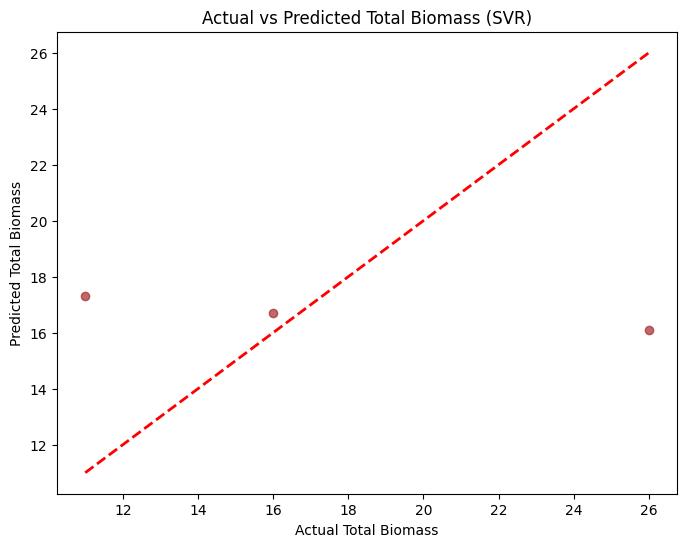

In [230]:
# Step 4: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, color='brown', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (SVR)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

Hyperparameter Tunning

In [231]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

In [232]:
# Initialize the SVR model
svr_model = SVR()

In [233]:
# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(svr_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='neg_mean_squared_error')

In [234]:

# Get the best parameters from the grid search
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'C': 10, 'epsilon': 1, 'kernel': 'linear'}


In [235]:
# Train the best model
best_svr_model = grid_search.best_estimator_

In [236]:
# Step 1: Make predictions
y_pred_svr = best_svr_model.predict(X_test_scaled)

In [237]:
# Step 2: Evaluate the model
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)

# Display results
print("Tuned SVR Model Evaluation:")
print(f"R-squared (R²): {r2_svr:.2f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")


Tuned SVR Model Evaluation:
R-squared (R²): -1.35
Mean Absolute Error (MAE): 9.36
Mean Squared Error (MSE): 91.48


R-squared (R² = -1.35):
The tuned Support Vector Regression (SVR) model has a negative R², indicating that it predicts worse than using the mean of the target variable. This suggests the model has not captured the relationship between the features and the target, leading to poor performance. This is actually worse than what would be expected from a naive model, and the performance shows no improvement from a simple average prediction.

Mean Absolute Error (MAE = 9.36):
The average prediction error is 9.36, meaning the model’s predictions are off by around 9.36 units on average. This error is significant, indicating poor model fit. Further tuning or a different model may be necessary for better accuracy.

Mean Squared Error (MSE = 91.48):
The squared prediction errors are quite large at 91.48, further confirming that the model is not capturing the underlying trends effectively. The high MSE suggests that there are substantial errors in the predictions, making this model less reliable.

Despite hyperparameter tuning, the SVR model remains poorly fitted, with a negative R² (-1.35) and high prediction errors (MAE: 9.36, MSE: 91.48). This suggests that there may be issues such as irrelevant features, insufficient data, or a mismatch between the model and data. Further feature engineering, data preprocessing, or exploring alternative models might be necessary for significant improvement.


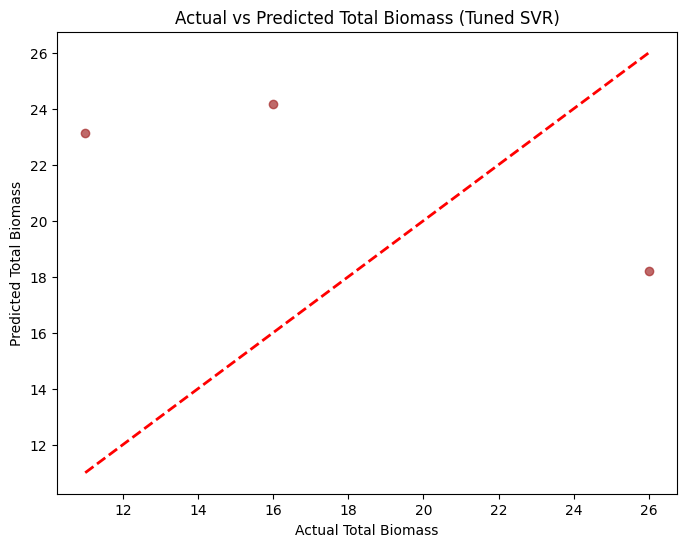

In [238]:
# Step 3: Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, color='brown', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Total Biomass (Tuned SVR)")
plt.xlabel("Actual Total Biomass")
plt.ylabel("Predicted Total Biomass")
plt.show()

All models (Linear Regression, Random Forest, Gradient Boosting, and SVR) performed poorly with negative R² values, indicating they failed to capture meaningful patterns in the data. The performance metrics (MAE and MSE) were consistently high across models, suggesting large prediction errors. Despite some improvements in error metrics with hyperparameter tuning (e.g., Random Forest, SVR), none of the models showed significant predictive power. This suggests issues such as irrelevant features, poor data quality, or a mismatch between the models and the data.
The models were tested using all relevant features, with species diversity yielding the best results overall. Based on the current performance, it appears that additional data would be beneficial for improving the model's accuracy, though it is unavailable at this time.